#**M2 Phase: Unsupervised Machine Learning for Grant Description and Sub-Topic Analysis**

**US Government Grant Opportunities Dataset**

By: Maggie Croghan Team 11

##**Domain Question**

How can clustering grant descriptions uncover meaningful sub-topic categories beyond broad classifications, and what do these finer-grained categories reveal about patterns of funding concentration, gaps, and potentially underserved areas within the grant landscape?

*Based on and modified from question 3 in M1*

##**Problem Statement**

This analysis dives into grant descriptions (from the *grant_opportunities_details* dataset) to discover the sub-domains within the broader categories and offer greater insight into what grants in these categories are actually serving. Each category is clustered independently and uses grant descriptions as the sole input. This analysis focuses on the five categories with the most grants to ensure each model has sufficient data points for clustering. Initial EDA revealed that the top categories, in order, were Health, Science, Education, Other, and Environment.

The domain question was reframed to specify the precise description characteristics this analysis would target. The characteristic of subject matter was chosen for the value it could provide to funding agencies who may be interested in diversifying their grants or to adovacy groups interested in the underserved groups within grant funding. Description complexity was also considered as characteristic for analysis, but initial EDA revealed more intriguing patterns within subject matter.



## **Data Import and Initial Cleaning**

In [ ]:
import pandas as pd
import numpy as np
import re

# IMPORT DATA
grants = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grants.csv",
    low_memory=False
)

details = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grant_opportunity_details.csv",
    low_memory=False
)


# CLEAN COLUMN NAMES
def clean_names(df):
    df.columns = (
        df.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
        .str.replace(r"[^\w]", "", regex=True)
    )
    return df

grants = clean_names(grants)
details = clean_names(details)


# CLEAN NUMERIC COLUMNS
numeric_cols = [
    "estimated_total_program_funding",
    "award_ceiling",
    "award_floor",
    "expected_number_of_awards"
]

for col in numeric_cols:
    if col in details.columns:
        details[col] = (
            details[col]
            .astype(str)
            .str.replace(r"[^\d.]", "", regex=True)
        )
        details[col] = pd.to_numeric(
            details[col],
            errors="coerce"
        ).fillna(0)


# CLEAN DATE COLUMNS
date_cols = [col for col in details.columns if "date" in col]

for col in date_cols:
    details[col] = pd.to_datetime(
        details[col],
        errors="coerce"
    )


# ENSURE BOOLEAN TYPE FOR ELIGIBILITY COLUMNS
eligibility_cols = [
    "eligibility_individuals",
    "eligibility_state_governments",
    "eligibility_county_governments",
    "eligibility_independent_school_districts",
    "eligibility_city_or_township_governments",
    "eligibility_special_district_governments",
    "eligibility_native_american_tribal_governments_federally_recognized",
    "eligibility_native_american_tribal_organizations_other",
    "eligibility_nonprofits_501c3",
    "eligibility_nonprofits_non_501c3",
    "eligibility_for_profit",
    "eligibility_small_businesses",
    "eligibility_private_institutions_of_higher_education",
    "eligibility_public_institutions_of_higher_education",
    "eligibility_public_indian_housing_authorities",
    "eligibility_others",
    "eligibility_unrestricted"
]

for col in eligibility_cols:
    if col in details.columns:
        details[col] = details[col].astype(bool)


# ENSURE BOOLEAN TYPE FOR FUNDING INSTRUMENT TYPES
funding_cols = [
    "funding_cooperative_agreement",
    "funding_grant",
    "funding_procurement_contract",
    "funding_other"
]

for col in funding_cols:
    if col in details.columns:
        details[col] = details[col].astype(bool)


# ENSURE BOOLEAN TYPE FOR ALL CATEGORY COLUMNS
category_cols = [
    "category_agriculture",
    "category_arts",
    "category_business",
    "category_community_development",
    "category_consumer_protection",
    "category_disaster",
    "category_education",
    "category_employment",
    "category_energy",
    "category_environment",
    "category_food",
    "category_health",
    "category_housing",
    "category_humanities",
    "category_iija",
    "category_income_security",
    "category_info",
    "category_law",
    "category_natural_resources",
    "category_opportunity_zone",
    "category_regional_development",
    "category_science",
    "category_transportation",
    "category_other"
]

for col in category_cols:
    if col in details.columns:
        details[col] = details[col].astype(bool)


# Fill missing descriptions
details['description'] = details['description'].fillna(details['funding_opportunity_title'])

# Create a single 'official_category' label by finding the first True category column
cat_cols = [c for c in details.columns if c.startswith('category_') and c != 'category_explanation']
details['official_category'] = details[cat_cols].idxmax(axis=1).str.replace('category_', '')

print("Grants shape:", grants.shape)
print("Details shape:", details.shape)

print("\nCategory columns:", len(category_cols))

details.head()

Grants shape: (74669, 17)
Details shape: (2000, 69)

Category columns: 24


,opportunity_id,funding_opportunity_number,funding_opportunity_title,opportunity_category,opportunity_category_explanation,expected_number_of_awards,cost_sharing_or_matching_requirement,version,posted_date,last_updated_date,...,category_info,category_law,category_natural_resources,category_opportunity_zone,category_regional_development,category_science,category_transportation,category_other,category_explanation,official_category
0,40112,DHS-FEMACAPSSSE-08-001,Community Assistance Program State Support Ser...,Discretionary,NaN,52.0,True,1,2007-11-28,2007-11-28,...,False,False,False,False,False,False,False,True,The purpose of the Community Assistance Progra...,other
1,40113,DHS-FEMACAPSSSE-08-001,Community Assistance Program State Support Ser...,Discretionary,NaN,52.0,True,1,2007-11-28,2007-11-28,...,False,False,False,False,False,False,False,True,The purpose of the Community Assistance Progra...,other
2,42048,FWS-R4-FLEXFUND,Southeast Region Flex Funds,Discretionary,NaN,25.0,False,3,2008-06-17,2008-06-18,...,False,False,True,False,False,False,False,False,NaN,natural_resources
3,42423,306-08-027-RFI,Alternative Development Program,Discretionary,NaN,1.0,False,1,2008-07-22,2008-07-22,...,False,False,False,False,False,False,False,False,NaN,agriculture
4,45657,04-563,Developing Country Collaborations in Plant Gen...,Discretionary,NaN,0.0,True,2,2004-03-22,2009-03-03,...,False,False,False,False,False,True,False,False,NaN,science


## **Additional EDA**

EDA in this notebook will focus on discovering patterns in grant descriptions and grant categories. Given the focus on grant descriptions, only the details dataset is used in this EDA.

### **1. Dataset Structure and Coverage**

In [ ]:
details.shape

(2000, 69)

In [ ]:
details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 69 columns):
 #   Column                                                               Non-Null Count  Dtype         
---  ------                                                               --------------  -----         
 0   opportunity_id                                                       2000 non-null   int64         
 1   funding_opportunity_number                                           2000 non-null   object        
 2   funding_opportunity_title                                            2000 non-null   object        
 3   opportunity_category                                                 2000 non-null   object        
 4   opportunity_category_explanation                                     53 non-null     object        
 5   expected_number_of_awards                                            2000 non-null   float64       
 6   cost_sharing_or_matching_requirement            

#### **1.1 How many grants are in each category?**

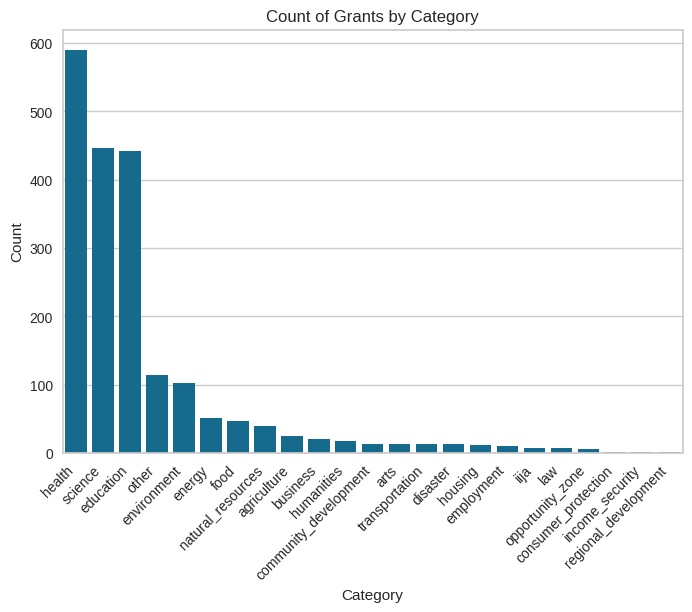

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=details, x='official_category', order=details['official_category'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Count of Grants by Category')
plt.show()

**Analysis**

This graph shows that most grants in this dataset are within the top three categories (Health, Science, Education). However, top five categories have grant counts greater than 100, which seemed a reasonable amount for clustering. Thus, my project will focus on these five categories.

### **2. Description Length and Complexity Analysis**

#### **2.1. What is the average character count, word count, sentence count, and sentence length of grants?**

In [ ]:
!pip install textstat --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 55.1 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords
import textstat

STOP_WORDS = set(stopwords.words("english"))

def tokenize(text):
    if pd.isna(text):
        return []
    words = re.findall(r"\b[a-z]+\b", text.lower())
    return [w for w in words if w not in STOP_WORDS]

def extract_text_features(df, text_col):
    df = df.copy()

    df["char_count"] = df[text_col].fillna("").str.len()
    df["word_count"] = df[text_col].apply(lambda x: len(tokenize(x)))
    df["unique_word_count"] = df[text_col].apply(lambda x: len(set(tokenize(x))))

    df["sentence_count"] = df[text_col].fillna("").str.count(r"[.!?]") + 1
    df["avg_sentence_length"] = (
        df["word_count"] / df["sentence_count"].replace(0, pd.NA)
    )

    df["flesch_reading_ease"] = df[text_col].apply(
        lambda x: textstat.flesch_reading_ease(x) if pd.notna(x) else None
    )

    df["fk_grade_level"] = df[text_col].apply(
        lambda x: textstat.flesch_kincaid_grade(x) if pd.notna(x) else None
    )

    return df

In [ ]:
df_text = extract_text_features(details, "description")
df_text[["char_count", "word_count", "unique_word_count", "sentence_count", "avg_sentence_length"]].describe()

,char_count,word_count,unique_word_count,sentence_count,avg_sentence_length
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1509.566000,138.219500,91.725000,11.218500,14.137261
std,1626.822889,148.867149,75.808673,14.595865,6.556991
min,3.000000,1.000000,1.000000,1.000000,1.000000
25%,635.000000,58.000000,46.000000,4.000000,10.583333
50%,985.000000,91.000000,68.000000,6.000000,13.666667
75%,1762.500000,162.000000,112.000000,12.000000,16.666667
max,16687.000000,1494.000000,695.000000,178.000000,197.333333


**Analysis**

While there are some extreme descriptions in both directions, 50% of descriptions are between 635 and 1762 characters, 58 and 162 words, and 4 and 12 sentences. The average sentence length is 14 words, with 75% of descriptions being 17 words or below. This is sentence length is logical, but one might expect more grants to have more technical or academic wording, and thus longer sentences.

In [ ]:
category_cols = [col for col in details.columns
            if col.startswith('category_') and col != 'category_explanation']

results = []

for cat in category_cols:
    filtered_df = df_text[df_text[cat] == True]
    mean_char_count = filtered_df['char_count'].mean()
    mean_word_count = filtered_df['word_count'].mean()
    mean_unique_word_count = filtered_df['unique_word_count'].mean()
    mean_sentence_count = filtered_df['sentence_count'].mean()
    mean_sentence_length = filtered_df['avg_sentence_length'].mean()
    mean_flesch_reading_ease = filtered_df['flesch_reading_ease'].mean()
    mean_fk_grade_level = filtered_df['fk_grade_level'].mean()
    results.append({'category': cat,
                    'mean_char_count': mean_char_count,
                    'mean_word_count': mean_word_count,
                    'mean_unique_word_count': mean_unique_word_count,
                    'mean_sentence_count': mean_sentence_count,
                    'mean_sentence_length': mean_sentence_length,
                    'mean_flesch_reading_ease': mean_flesch_reading_ease,
                    'mean_fk_grade_level': mean_fk_grade_level})

df_text_cat = pd.DataFrame(results)

df_text_cat[df_text_cat['category'].isin(["category_health", "category_science", "category_education", "category_other", "category_environment"])].loc[:,"category":"mean_sentence_length"]

,category,mean_char_count,mean_word_count,mean_unique_word_count,mean_sentence_count,mean_sentence_length
6,category_education,1004.600000,91.532609,67.406522,6.810870,14.840820
9,category_environment,1181.345622,108.433180,75.944700,9.023041,13.596206
11,category_health,901.987884,82.568500,61.879776,5.876048,15.019508
21,category_science,2765.707317,252.873984,152.398374,21.030488,13.796371
23,category_other,1807.984496,164.961240,107.201550,15.457364,12.588144


**Analysis**

Each of the top 5 categories reflect similar values to the overall dataset averages. Interestingly, there is not a correlation between sentence count and sentence length. Health, for example, has the longest average sentence length, but the smallest sentence count. Environement and Science categories both have a mean sentence length of 14 (rounded), but Environment grants have a mean sentence count of 9 compared to Science grants' mean sentence count of 21. This lack of correlation could indicate that length is not a good indicator of complexity.

#### **2.2. How complex are grant descriptions?**

**Flesch Reading Ease:** A readability formula that measures how easy a text is to understand, using a 0–100 scale (roughly) where higher scores indicate simpler text. A score of 60–70 generally considered ideal for the general public, equating to roughly 8th-9th grade level.

**FK Grade Level:** indicates the U.S. school grade a reader needs to understand a text, calculated using average sentence length and word complexity (syllables). A higher score (e.g., 12+) means more complex, academic text, while a lower score (e.g., 6-8) is easier for a general audience.

In [ ]:
df_text[["flesch_reading_ease", "fk_grade_level"]].describe()

,flesch_reading_ease,fk_grade_level
count,2000.000000,2000.000000
mean,4.639060,19.841625
std,22.096714,6.347860
min,-480.017000,-3.400000
25%,-5.692241,16.767728
50%,5.608705,19.195556
75%,16.465989,22.132048
max,121.220000,204.426000


In [ ]:
df_text_cat[df_text_cat['category'].isin(["category_health", "category_science", "category_education", "category_other", "category_environment"])][["category", "mean_flesch_reading_ease", "mean_fk_grade_level"]]

,category,mean_flesch_reading_ease,mean_fk_grade_level
6,category_education,2.001150,20.760086
9,category_environment,4.434679,19.933328
11,category_health,1.665469,20.917325
21,category_science,6.785742,18.835038
23,category_other,10.157253,18.216799


**Analysis**

All categories have complex descriptions with the average reading grade level being essentially equivalent to a third-year PhD student. While there is significant variance in complexity of grant descriptions, most are significantly under the thresholds considered ideal for the general public. Some of this complexity could be attributed to the inconsistent structure of descriptions, which could attribute to errors in sentence counting impact the scores. Even so, it seems reasonable to determine grant descriptions commonly use highly technical or burecratic language that is difficult for the average person to understand.

#### **2.3 Description Length by Complexity**

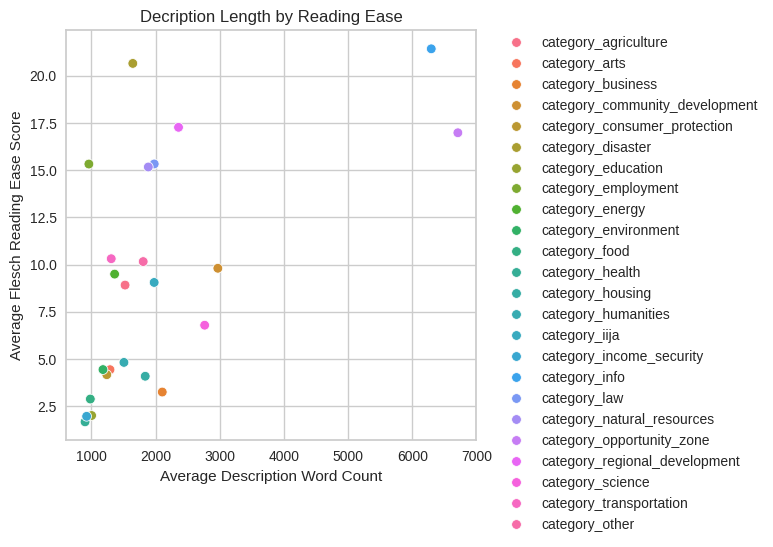

In [ ]:
sns.scatterplot(x="mean_char_count", y="mean_flesch_reading_ease", data=df_text_cat, hue="category")

plt.title("Decription Length by Reading Ease")
plt.xlabel("Average Description Word Count")
plt.ylabel("Average Flesch Reading Ease Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()

plt.show()

**Analysis**

Felsch reading score is calculated with the average number of words per sentence and syllables per word. Although there is a lot of variance, we can see that there is a very slight positive correlation between the complexity score with the length, indicating that longer descriptions may be both more beneficial for public interpretation and that greater care went into crafting useful descriptions.

#### **2.4 What is the Relationship Between Grant Description Lengths and Estimated Funding?**

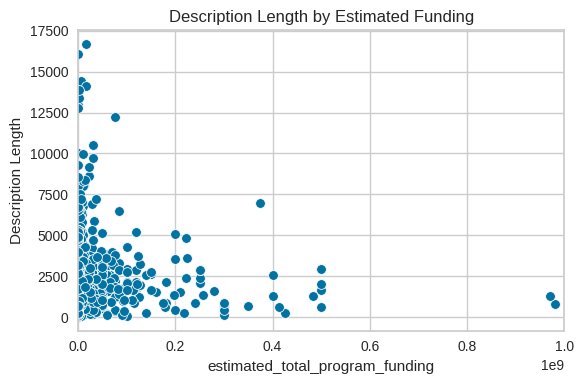

In [ ]:
details['description_length'] = details['description'].str.len()

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(x="estimated_total_program_funding", y="description_length", data=details, ax=ax)

plt.title("Description Length by Estimated Funding")
plt.ylabel("Description Length")
ax.set_xlim(0, 1000000000)
plt.tight_layout()
plt.show()

**Analysis**


Most grants are clusters below $200,000 in funding and below 5000 characters.Description length (character count) and estimated total program funding do not seem to be correlated, indicating that descriptions are not a crucial factor in grant opportunity postings, even for high funding grants.

###**3. Key Word Analysis**

#### 3.1. What are the most frequent words and phrases across all grants?

In [ ]:
from collections import Counter
from nltk.corpus import stopwords
from nltk.util import ngrams
import textstat
from sklearn.feature_extraction.text import TfidfVectorizer

def corpus_statistics(df, text_col, top_n=20):
    tokens = []
    df[text_col].dropna().apply(lambda x: tokens.extend(tokenize(x)))

    unigrams = Counter(tokens).most_common(top_n)

    bigrams = Counter(
        ngrams(tokens, 2)
    ).most_common(top_n)

    return {
        "top_unigrams": unigrams,
        "top_bigrams": bigrams
    }

def top_unigrams(df, text_col, top_n=20):
    tokens = []
    df[text_col].dropna().apply(lambda x: tokens.extend(tokenize(x)))
    return Counter(tokens).most_common(top_n)

def top_bigrams(df, text_col, top_n=20):
    tokens = []
    df[text_col].dropna().apply(lambda x: tokens.extend(tokenize(x)))
    return Counter(ngrams(tokens, 2)).most_common(top_n)

In [ ]:
top_words = top_unigrams(details, "description", top_n=20)
top_words

[('research', 6156),
 ('program', 3729),
 ('funding', 1860),
 ('support', 1829),
 ('development', 1676),
 ('clinical', 1522),
 ('projects', 1410),
 ('science', 1349),
 ('may', 1217),
 ('applications', 1217),
 ('foa', 1212),
 ('proposals', 1203),
 ('opportunity', 1184),
 ('data', 1041),
 ('health', 1034),
 ('award', 994),
 ('new', 915),
 ('must', 894),
 ('one', 854),
 ('announcement', 842)]

In [ ]:
top_phrases = top_bigrams(details, "description", top_n=10)
top_phrases

[(('funding', 'opportunity'), 964),
 (('opportunity', 'announcement'), 545),
 (('clinical', 'trial'), 489),
 (('announcement', 'foa'), 458),
 (('e', 'g'), 317),
 (('clinical', 'trials'), 296),
 (('program', 'elements'), 294),
 (('program', 'element'), 293),
 (('research', 'projects'), 278),
 (('united', 'states'), 250)]

**Analysis**

The top words and phrases across all grants are things we would expect to see, and dont offer much additional information into what the grants in this data set are really funding.

#### 3.2. What are the top words and phrases in each category?

In [ ]:
def subset_by_category(df, category_col):
    return df[df[category_col] == True]

def frequent_words_by_category(details, text_col, category_cols, top_n=20):
    return {
        cat: top_unigrams(
            subset_by_category(details, cat),
            text_col,
            top_n
        )
        for cat in category_cols
    }

top_cats = ["category_health", "category_science", "category_education", "category_other", "category_environment"]

top_words_by_cat = frequent_words_by_category(
    details,
    "description",
    top_cats,
    top_n=10
)

top_words_by_cat

{'category_health': [('research', 2700),
  ('clinical', 1124),
  ('foa', 963),
  ('funding', 874),
  ('support', 867),
  ('health', 808),
  ('development', 759),
  ('opportunity', 736),
  ('applications', 668),
  ('program', 655)],
 'category_science': [('research', 3227),
  ('program', 2231),
  ('science', 1093),
  ('proposals', 1048),
  ('may', 723),
  ('one', 608),
  ('roses', 606),
  ('support', 585),
  ('projects', 562),
  ('development', 535)],
 'category_education': [('research', 1229),
  ('clinical', 420),
  ('foa', 411),
  ('support', 405),
  ('cancer', 358),
  ('funding', 355),
  ('opportunity', 323),
  ('program', 322),
  ('development', 316),
  ('applications', 307)],
 'category_other': [('program', 285),
  ('funding', 209),
  ('development', 197),
  ('usaid', 162),
  ('grants', 141),
  ('u', 141),
  ('eligible', 140),
  ('economic', 139),
  ('planning', 135),
  ('aps', 132)],
 'category_environment': [('research', 447),
  ('program', 261),
  ('funding', 218),
  ('support',

In [ ]:
def frequent_phrases_by_category(details, text_col, category_cols, top_n=20):
    return {
        cat: top_bigrams(
            subset_by_category(details, cat),
            text_col,
            top_n
        )
        for cat in category_cols
    }

top_phrases_by_cat = frequent_phrases_by_category(
    details,
    "description",
    top_cats,
    top_n=10
)

top_phrases_by_cat

{'category_health': [(('funding', 'opportunity'), 669),
  (('opportunity', 'announcement'), 475),
  (('announcement', 'foa'), 417),
  (('clinical', 'trial'), 386),
  (('clinical', 'trials'), 194),
  (('research', 'projects'), 160),
  (('purpose', 'funding'), 147),
  (('notice', 'funding'), 141),
  (('career', 'development'), 129),
  (('opportunity', 'nofo'), 128)],
 'category_science': [(('program', 'elements'), 293),
  (('program', 'element'), 293),
  (('nasa', 'gov'), 211),
  (('nasaprs', 'com'), 171),
  (('science', 'nasa'), 168),
  (('gov', 'researchers'), 168),
  (('researchers', 'sara'), 168),
  (('e', 'g'), 167),
  (('http', 'science'), 138),
  (('arpa', 'e'), 128)],
 'category_education': [(('funding', 'opportunity'), 291),
  (('opportunity', 'announcement'), 208),
  (('announcement', 'foa'), 173),
  (('clinical', 'trial'), 131),
  (('research', 'projects'), 73),
  (('purpose', 'funding'), 65),
  (('clinical', 'trials'), 58),
  (('notice', 'funding'), 58),
  (('cancer', 'resear

**Analysis**

Even when inspecting grant categories individually, the top words and phrases in each tend to be similar to the top words overall.

We do get some insights in this analysis, however.

The science category seems to have many space grants as indicated by "roses" (a NASA program) and by multiple top phrases including NASA.

The education category seems to have some overlap with the health category, in the frequency of "clinical trials". Suprisingly, cancer research is a top word in education, but not in health or science.

The other category seems to have grants across economic developement, the private sector, and international development.

The Environement category, not suprisingly, seems to have "climate change" as a common theme across grants.


Overall, these words give a sub-optimal view into summarizing the types of iniatives these categories actual fund. Through unsupervvised machine learning, I have attempted to uncover the true themes across categories.

##**Unsupervised Machine Learning**

### Additional Cleaning

In [ ]:
# CLEAN TEXT COLUMNS
text_cols = [
    "description",
    "category_explanation",
    "additional_information_on_eligibility",
    "funding_opportunity_title"
]

for col in text_cols:
    if col in details.columns:
        details[col] = details[col].astype(str).str.strip()
        details[col] = details[col].str.lower()
        details[col] = details[col].apply(lambda x: re.sub(r"\s+", " ", x))  # remove whitespace
        details[col] = details[col].apply(lambda x: re.sub(r"[^\w\s]", "", x)) # remove special characters
        details[col] = details[col].apply(lambda x: re.sub(r"http\S+", " ", x)) # remove URLs
        details[col] = details[col].apply(lambda x: re.sub(r"\bu\.s\.\b", "us", x)) # normalize key grant terms


### **Health Category Clustering**

#### Check for Duplicate Descriptions

In [ ]:
details_health = details[details['official_category'] == 'health']
details_health.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor,description_length
count,590.000000,590.000000,590.000000,590,590,585,584,564,5.900000e+02,5.900000e+02,5.900000e+02,590.000000
mean,339878.200000,2.545763,1.452542,2022-06-07 15:42:06.101694976,2022-08-16 16:01:37.627118592,2024-09-06 09:43:23.076923136,2024-10-21 22:50:57.534246656,2024-12-22 01:39:34.468084992,6.000397e+06,3.896930e+06,2.547627e+05,901.637288
min,58617.000000,0.000000,1.000000,2010-11-01 00:00:00,2012-01-27 00:00:00,2011-04-15 00:00:00,2018-06-15 00:00:00,2023-10-29 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000
25%,335412.500000,0.000000,1.000000,2021-09-22 00:00:00,2021-12-12 18:00:00,2023-11-22 00:00:00,2023-12-05 00:00:00,2024-02-07 18:00:00,0.000000e+00,0.000000e+00,0.000000e+00,527.000000
50%,344395.500000,0.000000,1.000000,2022-11-10 00:00:00,2023-01-11 00:00:00,2024-07-05 00:00:00,2024-07-12 12:00:00,2024-10-11 12:00:00,0.000000e+00,0.000000e+00,0.000000e+00,781.000000
75%,348426.500000,0.000000,1.000000,2023-06-12 00:00:00,2023-06-29 18:00:00,2025-05-25 00:00:00,2025-05-26 00:00:00,2025-07-09 00:00:00,0.000000e+00,3.825000e+05,0.000000e+00,1133.500000
max,350383.000000,163.000000,18.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2031-12-06 00:00:00,2029-12-31 00:00:00,2040-01-01 00:00:00,5.000000e+08,5.000000e+08,7.300000e+07,4863.000000
std,20029.449628,12.579544,1.547313,NaN,NaN,NaN,NaN,NaN,3.749503e+07,2.908965e+07,3.340997e+06,588.325018


In [ ]:
details_health = details_health.drop_duplicates(subset="description")

In [ ]:
details_health.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor,description_length
count,554.000000,554.000000,554.000000,554,554,549,548,529,5.540000e+02,5.540000e+02,5.540000e+02,554.000000
mean,339539.907942,2.416968,1.481949,2022-05-25 08:32:03.465703936,2022-08-07 21:37:02.382671616,2024-08-31 23:15:24.590163968,2024-10-19 11:57:22.335766528,2024-12-20 12:17:41.625708800,5.644886e+06,4.137417e+06,2.713177e+05,922.068592
min,58617.000000,0.000000,1.000000,2010-11-01 00:00:00,2012-01-27 00:00:00,2011-04-15 00:00:00,2018-06-15 00:00:00,2023-10-29 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000
25%,334984.250000,0.000000,1.000000,2021-09-03 18:00:00,2021-11-21 12:00:00,2023-11-28 00:00:00,2023-12-05 00:00:00,2024-02-12 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,532.250000
50%,343952.500000,0.000000,1.000000,2022-10-27 00:00:00,2023-01-10 12:00:00,2024-06-20 00:00:00,2024-07-09 00:00:00,2024-08-20 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,821.000000
75%,348344.750000,0.000000,1.000000,2023-06-02 00:00:00,2023-06-28 00:00:00,2025-05-25 00:00:00,2025-05-29 06:00:00,2025-07-12 00:00:00,0.000000e+00,4.000000e+05,0.000000e+00,1152.500000
max,350383.000000,113.000000,18.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2031-12-06 00:00:00,2029-12-31 00:00:00,2040-01-01 00:00:00,5.000000e+08,5.000000e+08,7.300000e+07,4863.000000
std,20576.442922,11.025589,1.592432,NaN,NaN,NaN,NaN,NaN,3.457596e+07,3.000565e+07,3.447378e+06,598.834926


#### **Text Embedding**


In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

In [ ]:
embeddings_health = embedding_model.encode(
    details_health["description"].tolist(),   # convert to list for speed
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings_health = np.asarray(embeddings_health, dtype=np.float32)

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

In [ ]:
import umap

umap_model = umap.UMAP(
    n_components=15,
    n_neighbors=15,
    metric='cosine',
    random_state=42
)

embeddings_health_umap = umap_model.fit_transform(embeddings_health)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Grant descriptions were converted into numerical representations using a Sentence Transformer embedding model, which encodes each description into a dense vector capturing its semantic meaning rather than relying on keyword frequency alone. This approach enables clustering based on conceptual similarity between grants. To improve clustering efficiency and structure, Uniform Manifold Approximation and Projection (UMAP) was applied to reduce the high-dimensional embeddings into a lower-dimensional space while preserving their semantic relationships. The resulting vectors provide a compact, information-rich representation that supports accurate identification of sub-topic clusters within grant descriptions.

#### **K-Means Clustering**

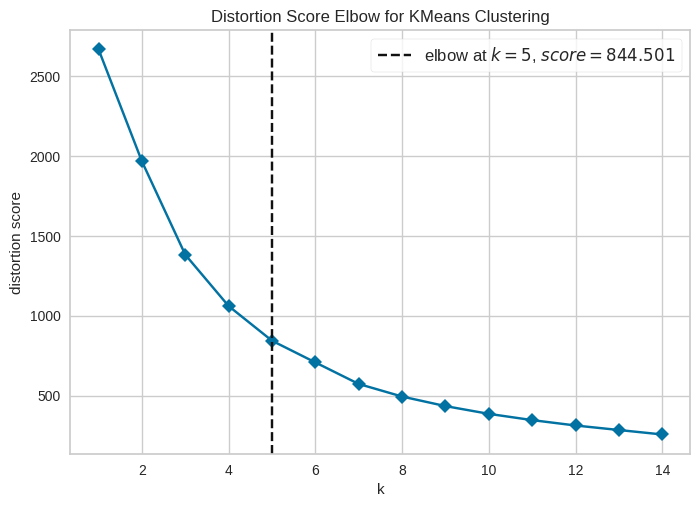

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(
    init="k-means++", # new
    n_init=10,      # increase iterations
    max_iter=500,   # new -- ensures convergence
    random_state=42
)

visualizer = KElbowVisualizer(
    model,
    k=(1, 15),                 # test cluster range
    metric="distortion",
    timings=False
)

visualizer.fit(embeddings_health_umap)
visualizer.show()

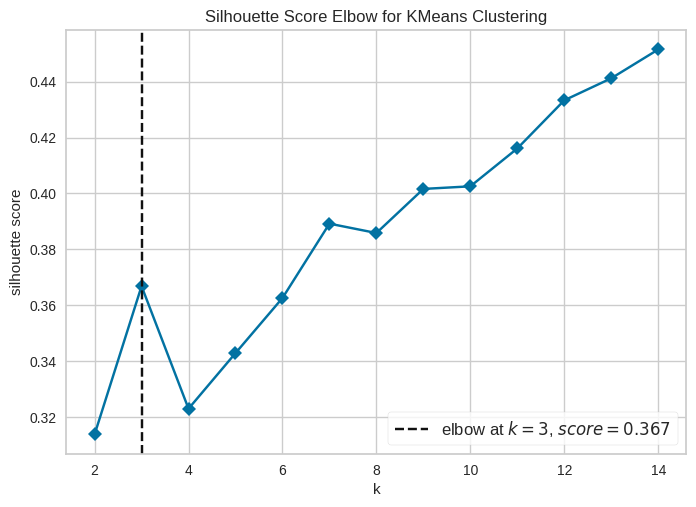

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
visualizer = KElbowVisualizer(
    model,
    k=(2, 15),                 # test cluster range
    metric="silhouette",
    timings=False
)

visualizer.fit(embeddings_health_umap)
visualizer.show()

In [ ]:
n_clusters = 7

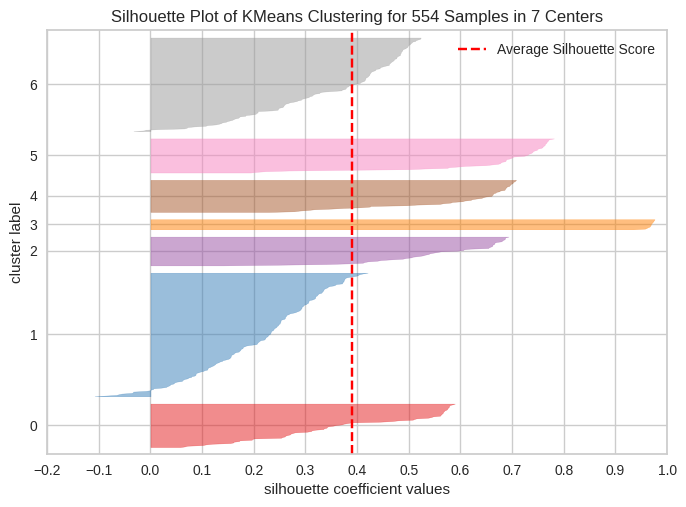

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 554 Samples in 7 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(
    n_clusters,
    init="k-means++", # new
    n_init=10,      # increase iterations
    max_iter=500,   # new -- ensures convergence
    random_state=42
)

visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(embeddings_health_umap)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

In [ ]:
# Fit the model and predict cluster labels, excluding the existing 'cluster_labels' column
details_health['cluster_labels'] = kmeans_model.fit_predict(embeddings_health_umap).astype(str)

# Display the value counts of the new cluster labels
print(details_health['cluster_labels'].value_counts())


cluster_labels
1    186
6    141
0     66
5     52
4     49
2     44
3     16
Name: count, dtype: int64


/tmp/ipython-input-65247215.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health['cluster_labels'] = kmeans_model.fit_predict(embeddings_health_umap).astype(str)


**Analysis**

Seven was chosen as the number of clusters for K-Means clustering, based on its lower distortion score and local maxima silhouette score. Seven is favored over a k of 3 or 5 as suggested by the elbow method for its higher silhoutte score and its ability to capture more specific sub-topics.

#### **Extracting Key Words from Each Cluster**

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

GRANT_STOPWORDS = [
    "grant", "grants",
    "funding", "funded",
    "proposal", "proposals",
    "applicant", "applicants",
    "application", "applications",
    "funding opportunity",
    "funding opportunity announcement",
    "opportunity announcement",
    "announcement",
    "program", "programs",
    "submit", "submission", "submitted",
    "eligible", "eligibility",
    "agency", "federal",
    "foa", "nofo", "cfda",
    "opportunity", "health"
]

custom_stopwords = list(ENGLISH_STOP_WORDS.union(GRANT_STOPWORDS))

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

word_vectorizer = TfidfVectorizer(
    stop_words=custom_stopwords,
    max_features=1000,
    ngram_range=(1, 1),
    min_df=5, # new
    max_df=0.85 # new
)

phrase_vectorizer = TfidfVectorizer(
    stop_words=custom_stopwords,
    max_features=1000,
    ngram_range=(2,3),
    min_df=5, # new
    max_df=0.85 # new
)

word_tfidf = word_vectorizer.fit_transform(details_health['description'])
word_terms = word_vectorizer.get_feature_names_out()

phrase_tfidf = phrase_vectorizer.fit_transform(details_health['description'])
phrase_terms = phrase_vectorizer.get_feature_names_out()


In [ ]:
def get_cluster_tfidf_summary(cluster_num, top_n=5):

    cluster_mask = (details_health['cluster_labels'] == str(cluster_num)).to_numpy()

    # WORDS
    cluster_word_matrix = word_tfidf[cluster_mask]
    word_means = np.asarray(cluster_word_matrix.mean(axis=0)).flatten()

    top_word_indices = word_means.argsort()[::-1][:top_n]

    top_words = [
        (word_terms[i], round(word_means[i], 4))
        for i in top_word_indices
    ]


    # PHRASES
    cluster_phrase_matrix = phrase_tfidf[cluster_mask]
    phrase_means = np.asarray(cluster_phrase_matrix.mean(axis=0)).flatten()

    top_phrase_indices = phrase_means.argsort()[::-1][:top_n]

    top_phrases = [
        (phrase_terms[i], round(phrase_means[i], 4))
        for i in top_phrase_indices
    ]

    return top_words, top_phrases

In [ ]:
num_clusters = details_health['cluster_labels'].nunique()

for cluster_num in range(num_clusters):

    words, phrases = get_cluster_tfidf_summary(cluster_num, top_n=5)

    print(f"\n========== Cluster {cluster_num} ==========")

    print("\nTop Words:")
    for word, score in words:
        print(f"{word:<20} {score}")

    print("\nTop Phrases:")
    for phrase, score in phrases:
        print(f"{phrase:<30} {score}")



========== Cluster 0 ==========

Top Words:
mental               0.1024
interventions        0.0778
clinical             0.0664
research             0.0655
nimh                 0.0575

Top Phrases:
mental disorders               0.0647
clinical trials                0.0625
mental services                0.0516
intended support               0.0467
clinical trial                 0.0441

========== Cluster 1 ==========

Top Words:
research             0.0977
clinical             0.0852
trial                0.0541
support              0.0421
development          0.0392

Top Phrases:
clinical trial                 0.057
clinical trials                0.0488
biomedical research            0.0339
small business                 0.0329
coordinating center            0.0283

========== Cluster 2 ==========

Top Words:
research             0.1497
occupational         0.1228
safety               0.1196
ahrq                 0.0996
niosh                0.088

Top Phrases:
occupational safety      

**Health Sub-Topics**

Cluster 0: Mental Health

Cluster 1: Clinical Trials

Cluster 2: Occupational Safety

Cluster 3: Research Education

Cluster 4: International Developement

Cluster 5: Independent Research & Career Development

Cluster 6: Alzheimers & Dementia

**Analysis**

With a silhoutte score under 0.4, we can expect some clusters to be poor. Particularly, there seems to be some overlap between Cluster 1 and Cluster 5. Overall, these are logical sub-domains for health grants to be funding and are more informative than a broad "health" category.

#### **Cluster Analysis**

In [ ]:
#assign sub-topic names to grants in details_health
cluster_name_mapping = {
    '0': 'mental health',
    '1': 'clinical trials',
    '2': 'occupational safety',
    '3': 'research education',
    '4': 'international development',
    '5': 'independent research & career development',
    '6': 'alzheimers & dementia'
}

if 'cluster_labels' not in details_health.columns:
    print("Error: 'cluster_labels' column not found. Please ensure the K-Means clustering cell was executed successfully.")
else:
    details_health['cluster_labels'] = details_health['cluster_labels'].map(cluster_name_mapping)


/tmp/ipython-input-3369405608.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health['cluster_labels'] = details_health['cluster_labels'].map(cluster_name_mapping)


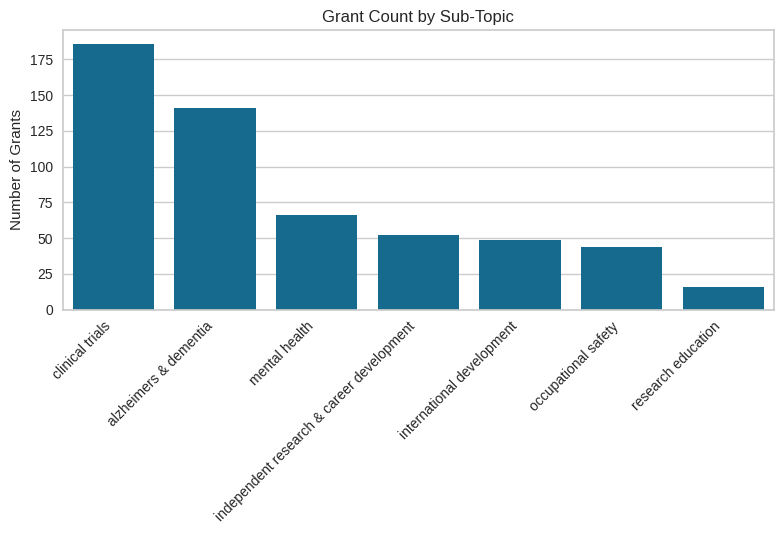

In [ ]:
#sub-topic count bar chart
sns.countplot(data=details_health, x='cluster_labels', order=details_health['cluster_labels'].value_counts().index)
plt.title("Grant Count by Sub-Topic")
plt.xlabel("")
plt.ylabel("Number of Grants")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analysis**

Clinical Trials leads in the number of grants in this category. Given the broad nature of this category, this aligns with intutition. Alzheimers follows this, with around 140 grants, indicating a strong focus on grants targeting this disease.

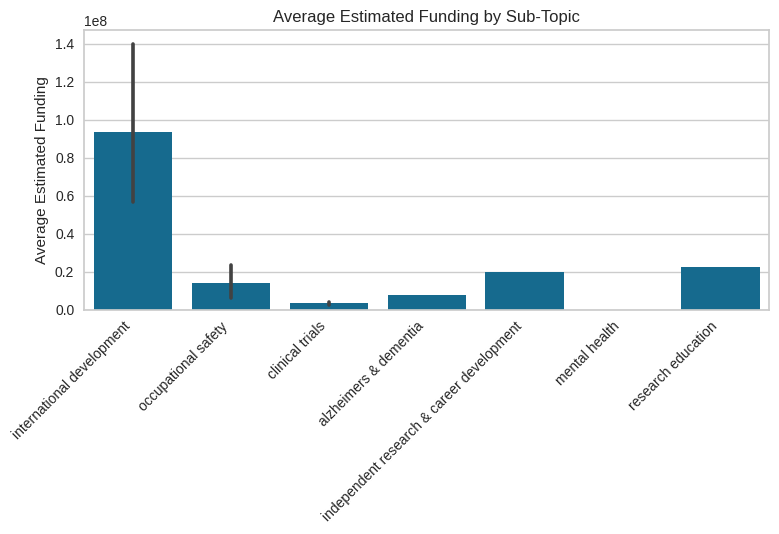

In [ ]:
#sub-topic by average estimated funding
sns.barplot(data=details_health, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Average Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Average Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analysis**

While Clinical Trials, Alzheimers, and Mental Health make up the greatest number of grants in Health, they represent the smallest average funding per grant. International Development, however, has significantly greateer average funding than all other sub-topics in health.

In [ ]:
#sub-topic by total estimated funding across all grants in the sub-topic

total_estimated_program_funding = pd.DataFrame(details_health.groupby('cluster_labels')['estimated_total_program_funding'].sum())
total_estimated_program_funding

,estimated_total_program_funding
cluster_labels,
alzheimers & dementia,7.500000e+06
clinical trials,6.500000e+06
independent research & career development,4.000000e+07
international development,2.714033e+09
mental health,0.000000e+00
occupational safety,3.367340e+08
research education,2.250000e+07


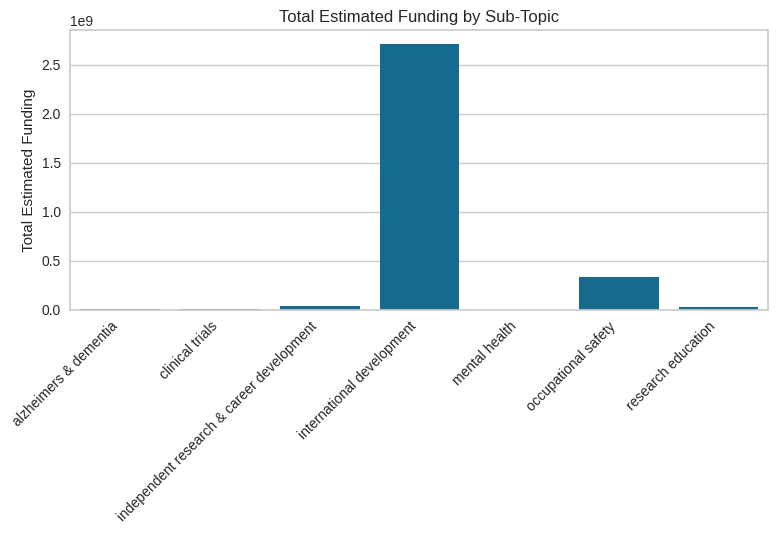

In [ ]:
sns.barplot(data=total_estimated_program_funding, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Total Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Total Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analysis**

When evaluating total funding across all grants in each sub domain, international development's funding lead is further expanded. Occupational Safety has the second highest total funding, while all other categories have comparatively insignificant funding. Clusters in mental health have a funding of zero, indicating missing data in the detail dataset.

### **Science Category Clustering**

#### Check for Duplicate Descriptions

In [ ]:
details_science = details[details['official_category'] == 'science']
details_science.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,447.000000,447.000000,447.000000,447,447,343,340,330,4.470000e+02,4.470000e+02,4.470000e+02
mean,332922.145414,2273.004474,4.762864,2021-12-08 11:45:30.201342208,2023-03-15 22:42:41.073825536,2023-02-26 09:56:09.096209920,2024-03-28 19:58:35.294117632,2026-01-12 21:01:05.454545408,2.628601e+07,1.035717e+07,2.940001e+06
min,45657.000000,0.000000,1.000000,2004-03-22 00:00:00,2009-03-03 00:00:00,2009-07-15 00:00:00,2023-09-27 00:00:00,2023-10-02 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,336030.000000,0.000000,1.000000,2021-10-07 12:00:00,2023-05-19 00:00:00,2023-01-18 12:00:00,2023-10-31 00:00:00,2023-12-16 06:00:00,0.000000e+00,0.000000e+00,0.000000e+00
50%,345446.000000,0.000000,3.000000,2023-01-19 00:00:00,2023-05-20 00:00:00,2023-10-03 00:00:00,2023-12-30 12:00:00,2024-10-03 00:00:00,3.200000e+06,0.000000e+00,0.000000e+00
75%,348284.500000,16.500000,5.000000,2023-05-22 00:00:00,2023-08-10 00:00:00,2023-12-06 12:00:00,2024-03-29 00:00:00,2026-12-22 00:00:00,1.200000e+07,2.500000e+05,5.000000e+03
max,350369.000000,999999.000000,62.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2043-05-10 00:00:00,2043-05-10 00:00:00,2043-06-09 00:00:00,5.000000e+09,1.000000e+09,1.000000e+09
std,42926.128536,47296.902015,6.357239,NaN,NaN,NaN,NaN,NaN,2.394688e+08,8.398423e+07,4.757381e+07


In [ ]:
details_science = details_science.drop_duplicates(subset="description")

In [ ]:
details_science.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,423.000000,423.000000,423.000000,423,423,319,316,306,4.230000e+02,4.230000e+02,4.230000e+02
mean,332149.286052,2401.874704,4.943262,2021-11-12 20:05:06.382978560,2023-03-12 12:11:54.893616896,2023-02-03 22:34:13.918495232,2024-04-01 20:12:09.113924096,2026-02-24 18:58:49.411764736,2.776086e+07,1.094481e+07,3.106810e+06
min,45657.000000,0.000000,1.000000,2004-03-22 00:00:00,2009-03-03 00:00:00,2009-07-15 00:00:00,2023-09-27 00:00:00,2023-10-02 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,335522.000000,0.000000,1.000000,2021-09-01 12:00:00,2023-05-19 00:00:00,2023-01-10 12:00:00,2023-10-30 00:00:00,2023-12-16 06:00:00,0.000000e+00,0.000000e+00,0.000000e+00
50%,345092.000000,1.000000,3.000000,2022-12-23 00:00:00,2023-05-20 00:00:00,2023-09-29 00:00:00,2023-12-16 12:00:00,2025-01-05 00:00:00,4.000000e+06,0.000000e+00,0.000000e+00
75%,348286.500000,20.000000,6.000000,2023-05-22 00:00:00,2023-08-10 00:00:00,2023-11-30 00:00:00,2024-03-14 06:00:00,2027-03-21 18:00:00,1.225000e+07,3.750000e+05,1.500000e+04
max,350369.000000,999999.000000,62.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2043-05-10 00:00:00,2043-05-10 00:00:00,2043-06-09 00:00:00,5.000000e+09,1.000000e+09,1.000000e+09
std,43998.870593,48620.052068,6.477566,NaN,NaN,NaN,NaN,NaN,2.461014e+08,8.630204e+07,4.890260e+07


#### **Text Embedding**

In [ ]:
embeddings_science = embedding_model.encode(
    details_science["description"].tolist(),   # convert to list for speed
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings_science = np.asarray(embeddings_science, dtype=np.float32)

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

In [ ]:
umap_model = umap.UMAP(
    n_components=15,
    n_neighbors=15,
    metric='cosine',
    random_state=42
)

embeddings_science_umap = umap_model.fit_transform(embeddings_science)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


####**K-Means Clustering**

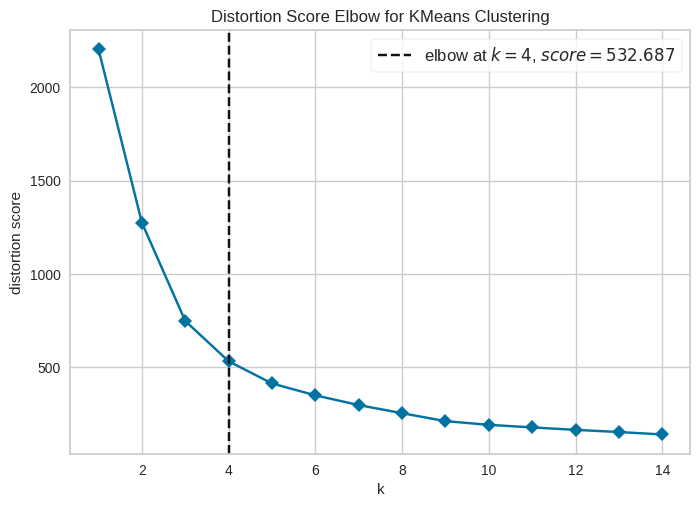

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
model = KMeans(
    init="k-means++", # new
    n_init=10,      # increase iterations
    max_iter=500,   # new -- ensures convergence
    random_state=42
)

visualizer = KElbowVisualizer(
    model,
    k=(1, 15),                 # test cluster range
    metric="distortion",
    timings=False
)

visualizer.fit(embeddings_science_umap)
visualizer.show()

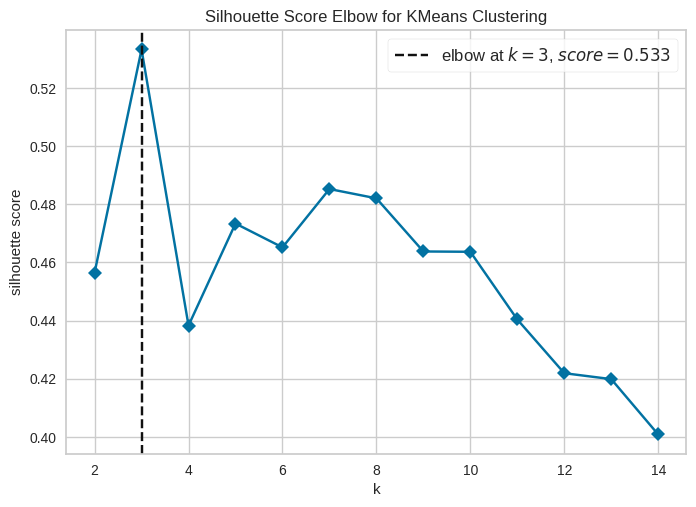

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
visualizer = KElbowVisualizer(
    model,
    k=(2, 15),                 # test cluster range
    metric="silhouette",
    timings=False
)

visualizer.fit(embeddings_science_umap)
visualizer.show()

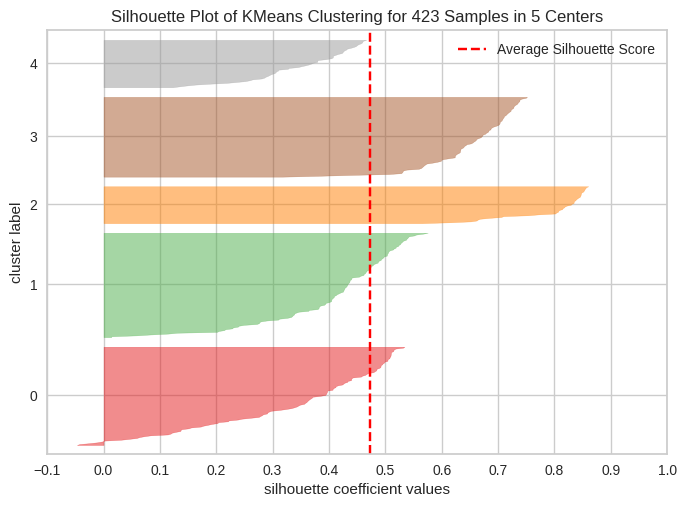

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 423 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = model = KMeans(
    n_clusters=5,
    init="k-means++",
    n_init=10,      # increase iterations
    max_iter=500,   # ensures convergence
    random_state=42
)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(embeddings_science_umap)        # Fit the data to the visualizer
visualizer.show()

In [ ]:
kmeans_model = model = KMeans(
    n_clusters=5,
    init="k-means++",
    n_init=10,      # increase iterations
    max_iter=500,   # ensures convergence
    random_state=42
)

# Fit the model and predict cluster labels, excluding the existing 'cluster_labels' column
details_science['cluster_labels'] = kmeans_model.fit_predict(embeddings_science_umap).astype(str)

# Display the value counts of the new cluster labels
print(details_science['cluster_labels'].value_counts())


cluster_labels
1    120
0    113
3     92
4     55
2     43
Name: count, dtype: int64


**Analysis**

A k value of 5 was chosen based on the silhouette local maxima at 5. While this is a lower silhoutte score than 3, and higher than the distortion elbow at 4, key words were extract at several different k's, and k=5 gave more informative clusters for sub-topic identification than k=3 or 4.

#### **Extracting Key Words From Each Cluster**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

word_vectorizer = TfidfVectorizer(
    stop_words=custom_stopwords,
    max_features=1000,
    ngram_range=(1, 1),
    min_df=5,
    max_df=0.80 # remove words appearing in 80% of descriptions
)

phrase_vectorizer = TfidfVectorizer(
    stop_words=custom_stopwords,
    max_features=1000,
    ngram_range=(2,3),
    min_df=5,
    max_df=0.80
)

word_tfidf = word_vectorizer.fit_transform(details_science['description'])
word_terms = word_vectorizer.get_feature_names_out()

phrase_tfidf = phrase_vectorizer.fit_transform(details_science['description'])
phrase_terms = phrase_vectorizer.get_feature_names_out()


In [ ]:
num_clusters = details_science['cluster_labels'].nunique()

for cluster_num in range(num_clusters):

    cluster_mask = (details_science['cluster_labels'] == str(cluster_num)).to_numpy()

    # WORDS
    cluster_word_matrix = word_tfidf[cluster_mask]
    word_means = np.asarray(cluster_word_matrix.mean(axis=0)).flatten()

    top_word_indices = word_means.argsort()[::-1][:5]

    words = [
        (word_terms[i], round(word_means[i], 4))
        for i in top_word_indices
    ]


    # PHRASES
    cluster_phrase_matrix = phrase_tfidf[cluster_mask]
    phrase_means = np.asarray(cluster_phrase_matrix.mean(axis=0)).flatten()

    top_phrase_indices = phrase_means.argsort()[::-1][:5]

    phrases = [
        (phrase_terms[i], round(phrase_means[i], 4))
        for i in top_phrase_indices
    ]

    print(f"\n========== Cluster {cluster_num} ==========")

    print("\nTop Words:")
    for word, score in words:
        print(f"{word:<20} {score}")

    print("\nTop Phrases:")
    for phrase, score in phrases:
        print(f"{phrase:<30} {score}")


========== Cluster 0 ==========

Top Words:
processes            0.0655
systems              0.0593
biological           0.0533
engineering          0.0433
earth                0.0394

Top Phrases:
supports research              0.0993
support research               0.0388
climate change                 0.0372
research infrastructure        0.0351
fundamental research           0.0335

========== Cluster 1 ==========

Top Words:
stem                 0.1115
education            0.0759
engineering          0.0643
nsf                  0.0629
science              0.0548

Top Phrases:
science engineering            0.0868
stem education                 0.0837
national science               0.0695
national science foundation    0.0596
science foundation             0.0593

========== Cluster 2 ==========

Top Words:
clinical             0.2295
award                0.1151
fy23                 0.1025
studies              0.0946
data                 0.0931

Top Phrases:
clinical trial         

**Science Sub-Topics**

Cluster 0: Earth, Biology, & Climate

Cluster 1: Engineering & National Science Foundation

Cluster 2: Clinical Trials & Awards

Cluster 3: Defense & Space

Cluster 4: Math & Social Behavioral Sciences

**Analysis**

With an average silhouette score just below 0.5, some clusters show clear sub-topics in science. Cluster 4, despite having the lowest silhouette score, capture both math and behavior science as sub-domains. Cluster 2 and 3 have the highest silhouette scores, with cluster 3 showing strong national defense and space themes, while cluster 2 captures themes also shown in other clusters. Cluster 0 and 1 also show informative sub-topics.

#### **Cluster Analysis**

In [ ]:
# assign sub-topic labels to each grant
cluster_name_mapping = {
    '0': 'earth, biology, & climate',
    '1': 'engineering & national science foundation',
    '2': 'clinical trials & awards',
    '3': 'defense & space',
    '4': 'math & social behavioral sciences'
}

if 'cluster_labels' not in details_science.columns:
    print("Error: 'cluster_labels' column not found. Please ensure the K-Means clustering cell was executed successfully.")
else:
    details_science['cluster_labels'] = details_science['cluster_labels'].map(cluster_name_mapping)

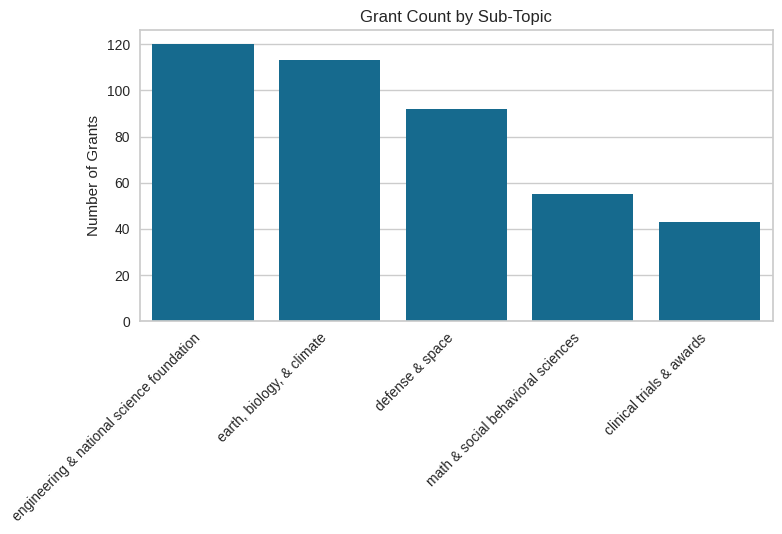

In [ ]:
#cluster count bar chart
sns.countplot(data=details_science, x='cluster_labels', order=details_science['cluster_labels'].value_counts().index)
plt.title("Grant Count by Sub-Topic")
plt.xlabel("")
plt.ylabel("Number of Grants")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analysis**

Engineering and Biology have the highest number of grants within Science. Clinical trials is the smallest sub-domain with 40 grants. This aligns with intuition, as clinical trials are often more aligned with health as a category.

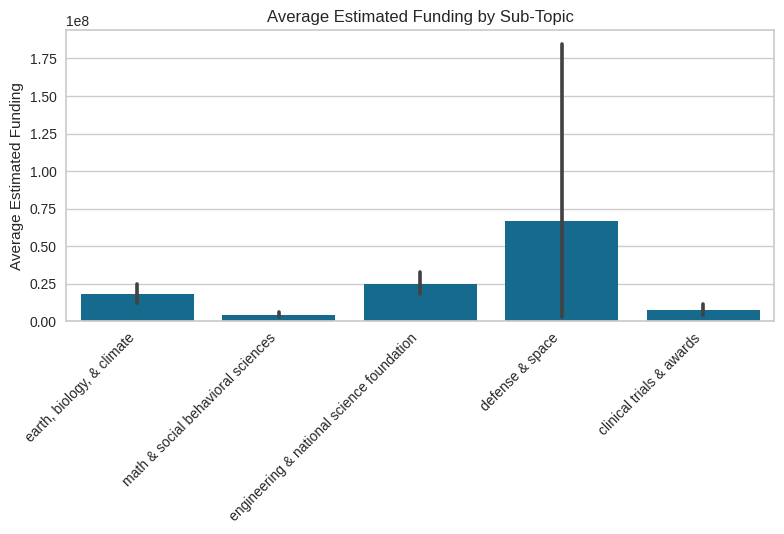

In [ ]:
#cluster by mean estimated funding
sns.barplot(data=details_science, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Average Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Average Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analysis**

Defense and Space have the largest average funding per grant. This aligns with broader US government spending trends, but the broad variance in this category may indicate a large variance in the focuses of these grants. Math and Behavioral Science have the smallest amount of average funding, indicating an area that may be underserved in grant funding.

In [ ]:
total_funding_science = pd.DataFrame(details_science.groupby('cluster_labels')['estimated_total_program_funding'].sum())
total_funding_science

,estimated_total_program_funding
cluster_labels,
clinical trials & awards,3.143320e+08
defense & space,6.167950e+09
"earth, biology, & climate",2.048063e+09
engineering & national science foundation,2.973400e+09
math & social behavioral sciences,2.391000e+08


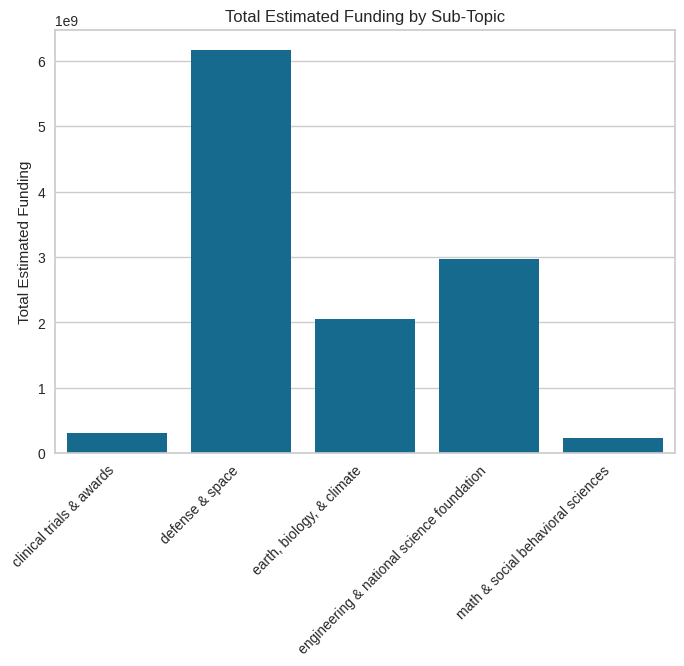

In [ ]:
sns.barplot(data=total_funding_science, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Total Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Total Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.show()

**Analysis**

When looking at total funding across all grants, similar patterns to average funding emerge that further confirm analysis about underserved areas within science.

### **Education Category Clustering**

#### Check for Duplicate Descriptions

In [ ]:
details_education = details[details['official_category'] == 'education']
details_education.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,442.000000,442.000000,442.000000,442,442,434,435,423,4.420000e+02,4.420000e+02,4.420000e+02
mean,338355.038462,0.287330,1.282805,2022-04-03 03:38:16.832579328,2022-07-21 07:52:23.891402752,2024-09-02 15:35:40.092165888,2024-12-24 05:11:10.344827648,2025-03-15 09:14:53.617021440,1.146605e+07,8.606184e+05,6.102941e+04
min,49325.000000,0.000000,1.000000,2009-09-02 00:00:00,2011-04-27 00:00:00,2009-07-29 00:00:00,2009-07-29 00:00:00,2023-10-29 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,335476.000000,0.000000,1.000000,2021-08-27 06:00:00,2021-12-10 18:00:00,2023-12-11 00:00:00,2024-02-01 00:00:00,2024-03-22 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
50%,342972.500000,0.000000,1.000000,2022-08-06 00:00:00,2022-12-10 00:00:00,2024-09-07 00:00:00,2024-09-07 00:00:00,2024-10-13 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
75%,348039.000000,0.000000,1.000000,2023-05-09 12:00:00,2023-05-23 00:00:00,2025-06-08 06:00:00,2025-06-17 00:00:00,2025-08-09 12:00:00,0.000000e+00,3.000000e+05,0.000000e+00
max,350389.000000,52.000000,18.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2028-02-08 00:00:00,2121-10-12 00:00:00,2121-11-11 00:00:00,4.350000e+09,6.000000e+07,1.000000e+07
std,24675.063168,2.837436,1.104156,NaN,NaN,NaN,NaN,NaN,2.071418e+08,4.898651e+06,6.610424e+05


In [ ]:
details_education = details_education.drop_duplicates(subset="description")

In [ ]:
details_education.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,397.000000,397.000000,397.000000,397,397,389,390,378,3.970000e+02,3.970000e+02,3.970000e+02
mean,338258.501259,0.319899,1.279597,2022-04-08 02:46:51.083123456,2022-07-10 14:34:09.370277120,2024-09-01 12:31:27.917737728,2024-12-26 01:39:41.538461696,2025-03-22 20:45:42.857143040,1.276573e+07,9.408752e+05,6.794711e+04
min,49325.000000,0.000000,1.000000,2009-09-02 00:00:00,2011-04-27 00:00:00,2009-07-29 00:00:00,2009-07-29 00:00:00,2023-10-29 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,335530.000000,0.000000,1.000000,2021-09-02 00:00:00,2021-11-22 00:00:00,2023-12-11 00:00:00,2024-01-08 00:00:00,2024-03-06 12:00:00,0.000000e+00,0.000000e+00,0.000000e+00
50%,343044.000000,0.000000,1.000000,2022-08-09 00:00:00,2022-11-22 00:00:00,2024-09-07 00:00:00,2024-09-07 00:00:00,2024-10-13 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
75%,348051.000000,0.000000,1.000000,2023-05-10 00:00:00,2023-05-26 00:00:00,2025-06-17 00:00:00,2025-06-19 06:00:00,2025-08-28 00:00:00,0.000000e+00,3.000000e+05,0.000000e+00
max,350389.000000,52.000000,18.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2028-02-08 00:00:00,2121-10-12 00:00:00,2121-11-11 00:00:00,4.350000e+09,6.000000e+07,1.000000e+07
std,25879.926324,2.992572,1.152473,NaN,NaN,NaN,NaN,NaN,2.185565e+08,5.162957e+06,6.972534e+05


#### **Text Embedding**

In [ ]:
embeddings_education = embedding_model.encode(
    details_education["description"].tolist(),   # convert to list for speed
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings_education = np.asarray(embeddings_education, dtype=np.float32)

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

In [ ]:
umap_model = umap.UMAP(
    n_components=15,
    n_neighbors=15,
    metric='cosine',
    random_state=42
)

embeddings_education_umap = umap_model.fit_transform(embeddings_education)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### **K-Means Clustering**

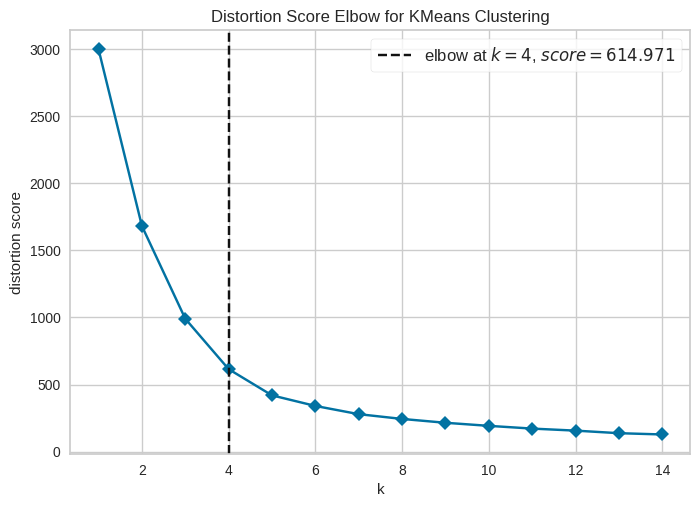

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
model = KMeans(
    init="k-means++", # enhanced initialization
    n_init=10,      # increase iterations
    max_iter=500,   # ensures convergence
    random_state=42
)

visualizer = KElbowVisualizer(
    model,
    k=(1, 15),                 # test cluster range
    metric="distortion",
    timings=False
)

visualizer.fit(embeddings_education_umap)
visualizer.show()

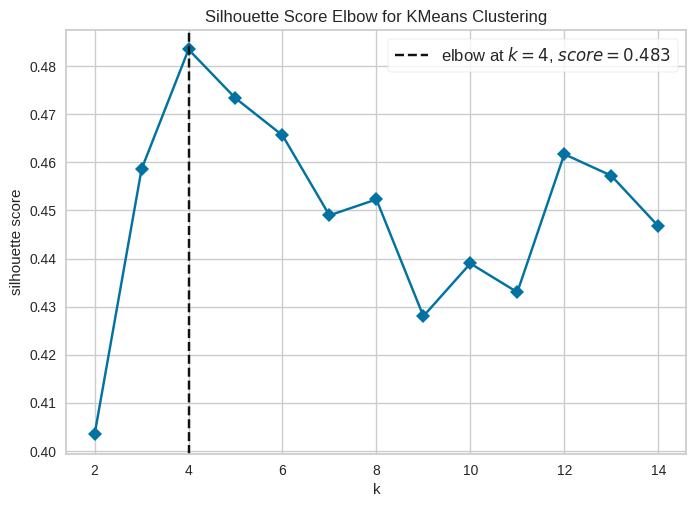

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
visualizer = KElbowVisualizer(
    model,
    k=(2, 15),                 # test cluster range
    metric="silhouette",
    timings=False
)

visualizer.fit(embeddings_education_umap)
visualizer.show()

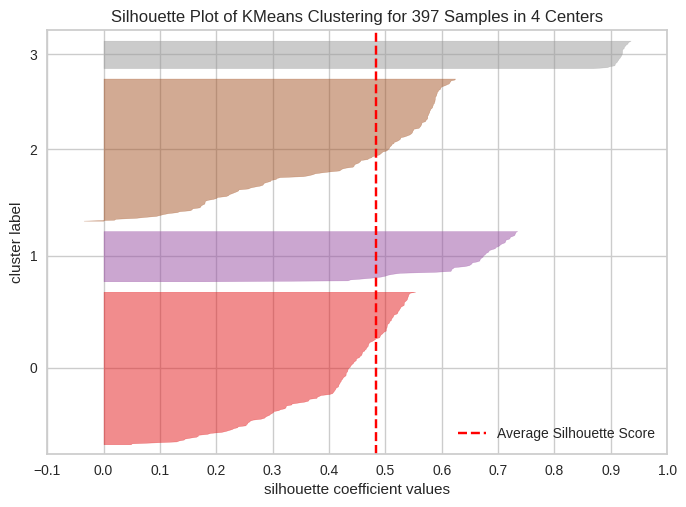

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 397 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
kmeans_model = model = KMeans(
    n_clusters=4,
    init="k-means++",
    n_init=10,
    max_iter=500,
    random_state=42
)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(embeddings_education_umap)        # Fit the data to the visualizer
visualizer.show()

In [ ]:
kmeans_model = model = KMeans(
    n_clusters=4,
    init="k-means++",
    n_init=10,
    max_iter=500,
    random_state=42
)

# Fit the model and predict cluster labels, excluding the existing 'cluster_labels' column
details_education['cluster_labels'] = kmeans_model.fit_predict(embeddings_education_umap).astype(str)

# Display the value counts of the new cluster labels
print(details_education['cluster_labels'].value_counts())


cluster_labels
0    162
2    151
1     54
3     30
Name: count, dtype: int64


**Analysis**

A k of 4 was choosen based off the elbow at k=4 for both distortion score and silhouette score.

#### **Extracting Key Words From Each Cluster**

In [ ]:
word_tfidf_education = word_vectorizer.fit_transform(details_education['description'])
word_terms_education = word_vectorizer.get_feature_names_out()

phrase_tfidf_education = phrase_vectorizer.fit_transform(details_education['description'])
phrase_terms_education = phrase_vectorizer.get_feature_names_out()


In [ ]:
num_clusters_education = details_education['cluster_labels'].nunique()

for cluster_num in range(num_clusters_education):

    cluster_mask = (details_education['cluster_labels'] == str(cluster_num)).to_numpy()

    # WORDS
    cluster_word_matrix = word_tfidf_education[cluster_mask]
    word_means = np.asarray(cluster_word_matrix.mean(axis=0)).flatten()

    top_word_indices = word_means.argsort()[::-1][:5]

    words = [
        (word_terms_education[i], round(word_means[i], 4))
        for i in top_word_indices
    ]


    # PHRASES
    cluster_phrase_matrix = phrase_tfidf_education[cluster_mask]
    phrase_means = np.asarray(cluster_phrase_matrix.mean(axis=0)).flatten()

    top_phrase_indices = phrase_means.argsort()[::-1][:5]

    phrases = [
        (phrase_terms_education[i], round(phrase_means[i], 4))
        for i in top_phrase_indices
    ]

    print(f"\n========== Cluster {cluster_num} ==========")

    print("\nTop Words:")
    for word, score in words:
        print(f"{word:<20} {score}")

    print("\nTop Phrases:")
    for phrase, score in phrases:
        print(f"{phrase:<30} {score}")


========== Cluster 0 ==========

Top Words:
use                  0.053
hiv                  0.0454
pain                 0.0431
brain                0.0395
substance            0.0378

Top Phrases:
substance use                  0.0629
drug abuse                     0.0362
purpose support                0.0359
brain initiative               0.033
use disorders                  0.0317

========== Cluster 1 ==========

Top Words:
independent          0.1159
clinical             0.1122
trial                0.1059
nih                  0.1047
training             0.0843

Top Phrases:
clinical trial                 0.0974
career development             0.0754
research training              0.0585
research education             0.0544
purpose nih                    0.0528

========== Cluster 2 ==========

Top Words:
cancer               0.1309
clinical             0.0576
studies              0.0448
data                 0.0417
projects             0.0406

Top Phrases:
research projects        

**Education Sub-Topics**

Cluster 0: Substance Use, HIV, & Brain Initatives

Cluster 1: Clinical Trials

Cluster 2: Cancer Research

Cluster 3: STEM Education, Higher Education, & International Development

**Analysis**

Despite a silhouette score similar to previous categories (0.483), the key words extracted from each cluster are less informative. Cluster 2 shows a clear cancer sub-topic, but other clusters show various topics, low tfidf scores for key words, or generic grant key words.

#### **Cluster Analysis**

In [ ]:
# assign sub-topic labels to each grant
cluster_name_mapping = {
    '0': 'Substance Use, HIV, & Brain Initatives',
    '1': 'Clinical Trials',
    '2': 'Cancer Research',
    '3': 'STEM Education, Higher Education, & International Development',
}

if 'cluster_labels' not in details_education.columns:
    print("Error: 'cluster_labels' column not found. Please ensure the K-Means clustering cell was executed successfully.")
else:
    details_education['cluster_labels'] = details_education['cluster_labels'].map(cluster_name_mapping)

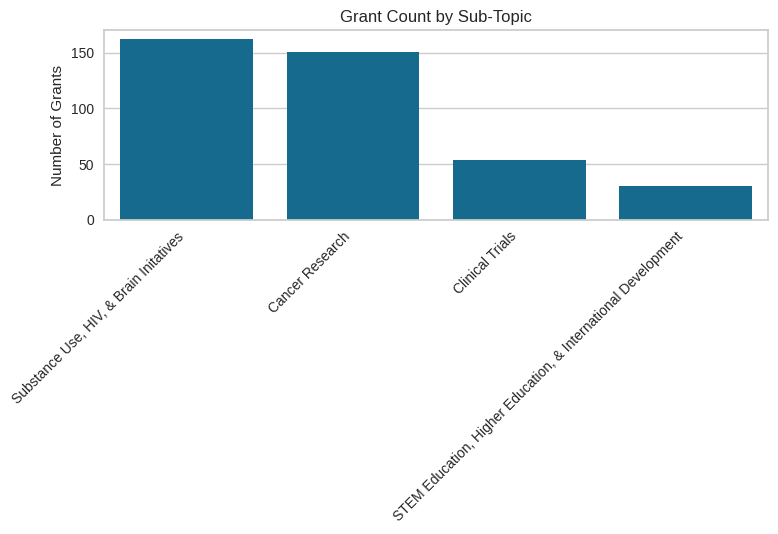

In [ ]:
#cluster count bar chart
sns.countplot(data=details_education, x='cluster_labels', order=details_education['cluster_labels'].value_counts().index)
plt.title("Grant Count by Sub-Topic")
plt.xlabel("")
plt.ylabel("Number of Grants")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analysis**

Substance Use and Cancer research have the highest number of grants within education, however, the substance use cluster captures more topics, indicating a high presence of cancer education grants. The STEM sub-topic has the smallest number of grants, despite the broad nature of the cluster. Suprisingly, clinical trials appears in education, just as it has for the two previous categories.

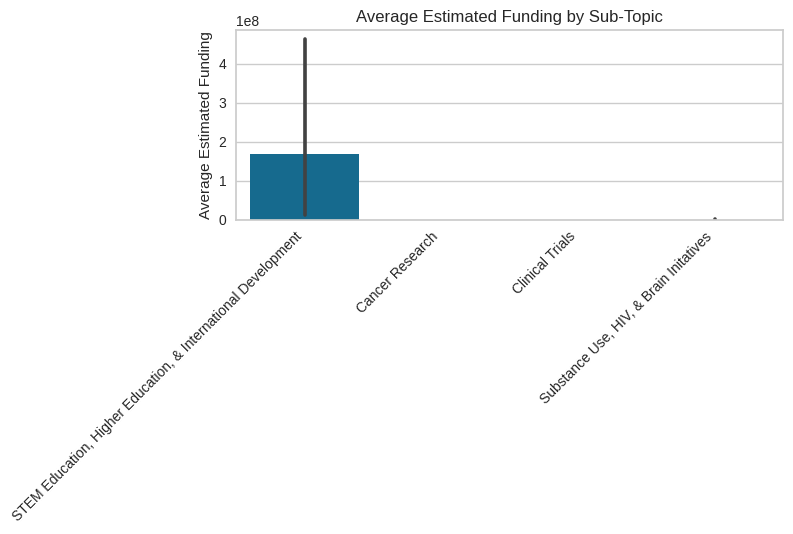

In [ ]:
#cluster by mean estimated funding
sns.barplot(data=details_education, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Average Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Average Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analysis**

Despite STEM have the smallest share of education grants, it has the highest average funding. This is likely due to a few high funding grants, as seen by the large variance.

In [ ]:
total_funding_education = pd.DataFrame(details_education.groupby('cluster_labels')['estimated_total_program_funding'].sum())
total_funding_education

,estimated_total_program_funding
cluster_labels,
Cancer Research,0.000000e+00
Clinical Trials,0.000000e+00
"STEM Education, Higher Education, & International Development",5.025996e+09
"Substance Use, HIV, & Brain Initatives",4.200000e+07


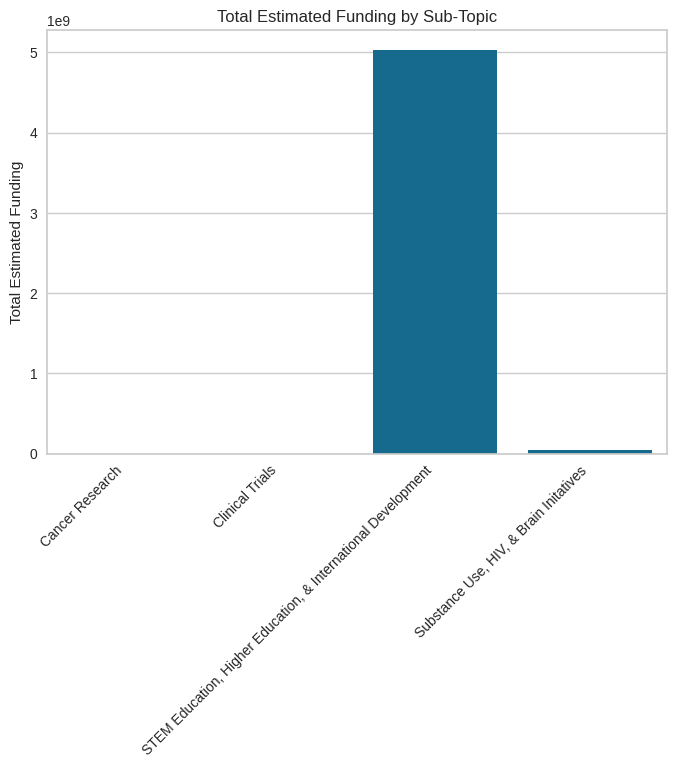

In [ ]:
sns.barplot(data=total_funding_education, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Total Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Total Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.show()

**Analysis**

Cancer and Clinical Trails both have a total program funding of zero, indicating missing values in the dataset or grant opportunities with incomplete information. While the substance use sub-topic does have a high overall funding, it is increadibly outweighed by the STEM sub-topic.

### **Other Category Clustering**

#### Check for Duplicate Descriptions

In [ ]:
details_other = details[details['official_category'] == 'other']
details_other.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,114.000000,114.000000,114.000000,114,114,71,71,46,1.140000e+02,1.140000e+02,1.140000e+02
mean,314469.192982,33.245614,3.307018,2020-10-20 23:47:22.105263104,2021-04-12 06:18:56.842105344,2027-08-16 12:30:25.352112640,2028-02-24 11:49:51.549295872,2024-03-13 15:39:07.826086912,2.054306e+07,1.039419e+07,8.812939e+05
min,40112.000000,0.000000,1.000000,2007-11-28 00:00:00,2007-11-28 00:00:00,2017-12-18 00:00:00,2017-08-13 00:00:00,2023-10-29 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,317601.250000,0.000000,1.000000,2019-07-16 12:00:00,2020-12-27 00:00:00,2023-06-15 12:00:00,2023-09-30 00:00:00,2023-11-18 06:00:00,0.000000e+00,2.000000e+04,0.000000e+00
50%,341915.000000,1.000000,2.000000,2022-07-05 00:00:00,2023-01-30 12:00:00,2023-10-06 00:00:00,2023-11-16 00:00:00,2024-01-16 12:00:00,0.000000e+00,3.000000e+05,1.000000e+03
75%,348591.750000,5.000000,4.750000,2023-06-06 12:00:00,2023-07-23 00:00:00,2023-12-26 12:00:00,2024-03-21 12:00:00,2024-05-08 00:00:00,4.000000e+06,4.935000e+06,1.000000e+05
max,350362.000000,3000.000000,19.000000,2023-09-27 00:00:00,2023-09-28 00:00:00,2099-01-01 00:00:00,2099-01-01 00:00:00,2025-05-26 00:00:00,5.000000e+08,3.749813e+08,3.080000e+07
std,70362.197925,280.918328,3.320964,NaN,NaN,NaN,NaN,NaN,7.832983e+07,3.918548e+07,3.469931e+06


In [ ]:
details_other = details_other.drop_duplicates(subset="description")

In [ ]:
details_other.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,106.000000,106.000000,106.000000,106,106,71,71,46,1.060000e+02,1.060000e+02,1.060000e+02
mean,317029.679245,35.264151,3.283019,2021-01-05 00:40:45.283018752,2021-06-07 07:28:18.113207552,2027-08-16 12:30:25.352112640,2028-02-24 11:49:51.549295872,2024-03-13 15:39:07.826086912,2.202272e+07,1.108809e+07,9.478067e+05
min,40112.000000,0.000000,1.000000,2007-11-28 00:00:00,2007-11-28 00:00:00,2017-12-18 00:00:00,2017-08-13 00:00:00,2023-10-29 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,325882.500000,0.000000,1.000000,2020-03-30 18:00:00,2021-09-09 06:00:00,2023-06-15 12:00:00,2023-09-30 00:00:00,2023-11-18 06:00:00,0.000000e+00,1.500000e+04,0.000000e+00
50%,344043.500000,1.000000,2.000000,2022-10-13 00:00:00,2023-02-11 00:00:00,2023-10-06 00:00:00,2023-11-16 00:00:00,2024-01-16 12:00:00,0.000000e+00,5.000000e+05,2.500000e+03
75%,348756.000000,5.000000,4.000000,2023-07-07 00:00:00,2023-07-26 18:00:00,2023-12-26 12:00:00,2024-03-21 12:00:00,2024-05-08 00:00:00,4.555000e+06,5.000000e+06,1.825000e+05
max,350362.000000,3000.000000,19.000000,2023-09-27 00:00:00,2023-09-28 00:00:00,2099-01-01 00:00:00,2099-01-01 00:00:00,2025-05-26 00:00:00,5.000000e+08,3.749813e+08,3.080000e+07
std,67747.210249,291.284293,3.362977,NaN,NaN,NaN,NaN,NaN,8.106213e+07,4.056024e+07,3.590842e+06


#### **Text Embedding**

In [ ]:
embeddings_other = embedding_model.encode(
    details_other["description"].tolist(),   # convert to list for speed
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings_other = np.asarray(embeddings_other, dtype=np.float32)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
umap_model = umap.UMAP(
    n_components=15,
    n_neighbors=15,
    metric='cosine',
    random_state=42
)

embeddings_other_umap = umap_model.fit_transform(embeddings_other)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### **K-Means Clustering**

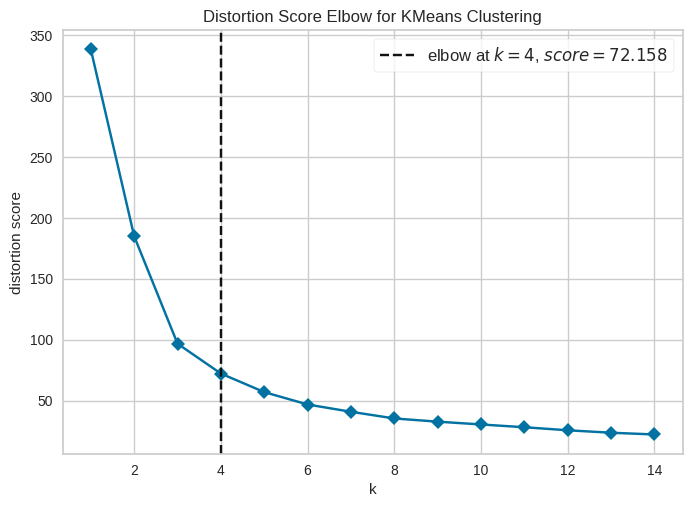

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
model = KMeans(
    init="k-means++", # enhanced initialization
    n_init=10,      # increase iterations
    max_iter=500,   # ensures convergence
    random_state=42
)

visualizer = KElbowVisualizer(
    model,
    k=(1, 15),                 # test cluster range
    metric="distortion",
    timings=False
)

visualizer.fit(embeddings_other_umap)
visualizer.show()

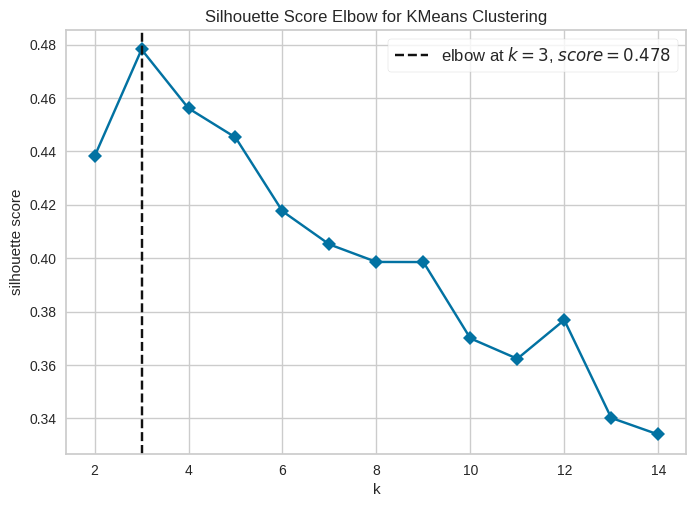

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
visualizer = KElbowVisualizer(
    model,
    k=(2, 15),                 # test cluster range
    metric="silhouette",
    timings=False
)

visualizer.fit(embeddings_other_umap)
visualizer.show()

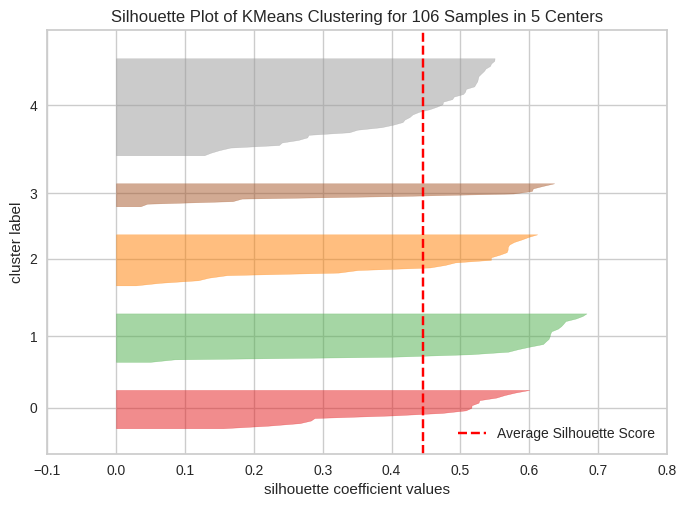

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 106 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
kmeans_model = model = KMeans(
    n_clusters=5,
    init="k-means++",
    n_init=10,
    max_iter=500,
    random_state=42
)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(embeddings_other_umap)        # Fit the data to the visualizer
visualizer.show()

In [ ]:
# Fit the model and predict cluster labels, excluding the existing 'cluster_labels' column
details_other['cluster_labels'] = kmeans_model.fit_predict(embeddings_other_umap).astype(str)

# Display the value counts of the new cluster labels
print(details_other['cluster_labels'].value_counts())


cluster_labels
4    39
2    21
1    20
0    16
3    10
Name: count, dtype: int64


**Analysis**

A k value of 5 was chosen after testing k's of 3 and 4, chosen based off elbow tests, because it lead to more informative key word clusters. k=5 provides the 3rd highest average silhouette value, before dropping off in value at k=6.

#### **Extracting Key Words From Each Cluster**

In [ ]:
word_tfidf_other = word_vectorizer.fit_transform(details_other['description'])
word_terms_other = word_vectorizer.get_feature_names_out()

phrase_tfidf_other = phrase_vectorizer.fit_transform(details_other['description'])
phrase_terms_other = phrase_vectorizer.get_feature_names_out()


In [ ]:
num_clusters_other = details_other['cluster_labels'].nunique()

for cluster_num in range(num_clusters_other):

    cluster_mask = (details_other['cluster_labels'] == str(cluster_num)).to_numpy()

    # WORDS
    cluster_word_matrix = word_tfidf_other[cluster_mask]
    word_means = np.asarray(cluster_word_matrix.mean(axis=0)).flatten()

    top_word_indices = word_means.argsort()[::-1][:5]

    words = [
        (word_terms_other[i], round(word_means[i], 4))
        for i in top_word_indices
    ]


    # PHRASES
    cluster_phrase_matrix = phrase_tfidf_other[cluster_mask]
    phrase_means = np.asarray(cluster_phrase_matrix.mean(axis=0)).flatten()

    top_phrase_indices = phrase_means.argsort()[::-1][:5]

    phrases = [
        (phrase_terms_other[i], round(phrase_means[i], 4))
        for i in top_phrase_indices
    ]

    print(f"\n========== Cluster {cluster_num} ==========")

    print("\nTop Words:")
    for word, score in words:
        print(f"{word:<20} {score}")

    print("\nTop Phrases:")
    for phrase, score in phrases:
        print(f"{phrase:<30} {score}")


========== Cluster 0 ==========

Top Words:
labor                0.2006
agreement            0.1019
cooperative          0.0762
notice               0.0716
department           0.0689

Top Phrases:
cooperative agreement          0.1672
notice intent                  0.1239
international labor            0.1221
fiscal year                    0.0925
labor affairs                  0.0887

========== Cluster 1 ==========

Top Words:
embassy              0.1058
cultural             0.0961
american             0.0928
public               0.0857
include              0.0833

Top Phrases:
united states                  0.1793
public diplomacy               0.1304
human rights                   0.1157
civil society                  0.0966
department state               0.0831

========== Cluster 2 ==========

Top Words:
economic             0.1104
eda                  0.1066
planning             0.0971
state                0.0848
edge                 0.0743

Top Phrases:
economic development   

**Other Sub-Topics**

Cluster 0: Labor Affairs & Cooperations

Cluster 1: Public Diplomacy & Human Rights

Cluster 2: Economic Development

Cluster 3: Historical and Cultural Preservation

Cluster 4: Private Sector

**Analysis**

All clusters showed similar average silhouette values, with the total average being 0.45, indicating weak but reasonable clustering. The sub-topics identified show clear sub-topics, but it is reasonable to assume a larger variety in the "other" category than in more defined grant categories.

#### **Cluster Analysis**

In [ ]:
# assign sub-topic labels to each grant
cluster_name_mapping = {
    '0': 'Labor Affairs & Cooperations',
    '1': 'Public Diplomacy & Human Rights',
    '2': 'Economic Development',
    '3': 'Historical and Cultural Preservation',
    '4': 'Private Sector'
}

if 'cluster_labels' not in details_other.columns:
    print("Error: 'cluster_labels' column not found. Please ensure the K-Means clustering cell was executed successfully.")
else:
    details_other['cluster_labels'] = details_other['cluster_labels'].map(cluster_name_mapping)

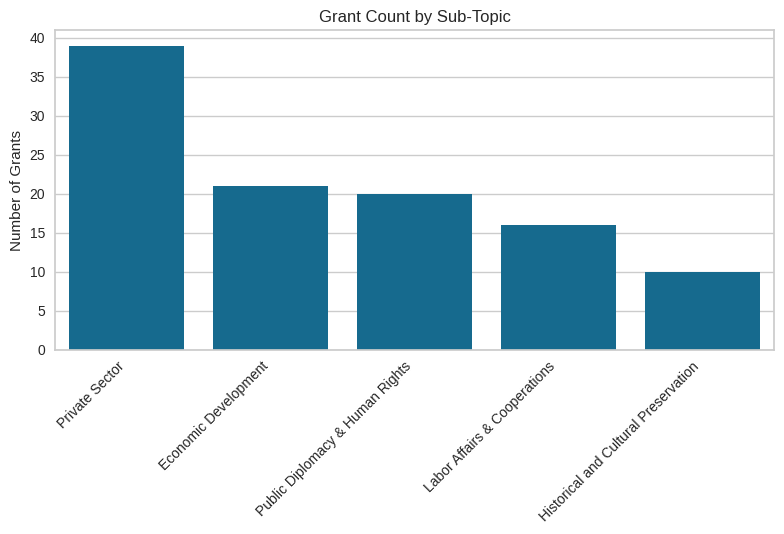

In [ ]:
#cluster count bar chart
sns.countplot(data=details_other, x='cluster_labels', order=details_other['cluster_labels'].value_counts().index)
plt.title("Grant Count by Sub-Topic")
plt.xlabel("")
plt.ylabel("Number of Grants")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analysis**

Private Sector and Economic Development have the largest proportion of grants in the other category, while historical and cultural preservation has only 10 grants. This could be attributed to similar grants being categorized in other broad grant categories.

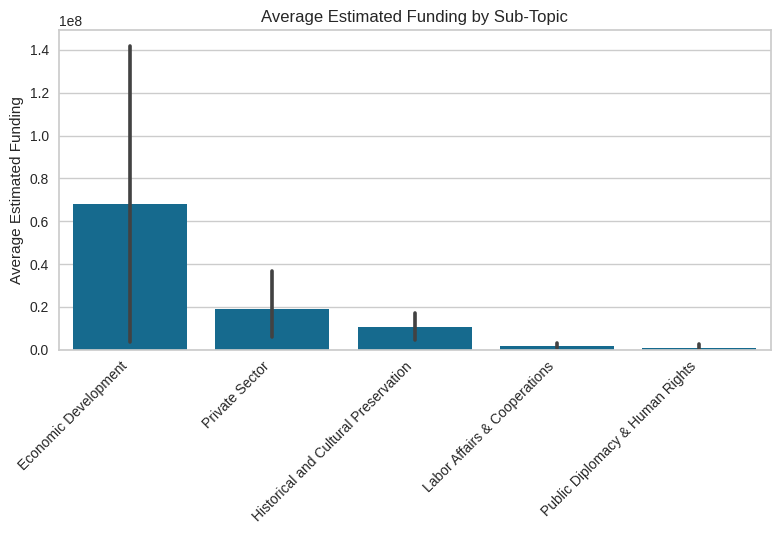

In [ ]:
#cluster by mean estimated funding
sns.barplot(data=details_other, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Average Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Average Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analysis**

Economic development has the highest average funding per grant, followed by the private sector. Given the share of these grants is also the greatest in this category, we can conclude that these sub-domains dominate the 'other' category.

In [ ]:
total_funding_other = pd.DataFrame(details_other.groupby('cluster_labels')['estimated_total_program_funding'].sum())
total_funding_other

,estimated_total_program_funding
cluster_labels,
Economic Development,1.432731e+09
Historical and Cultural Preservation,1.052915e+08
Labor Affairs & Cooperations,2.932075e+07
Private Sector,7.484000e+08
Public Diplomacy & Human Rights,1.866500e+07


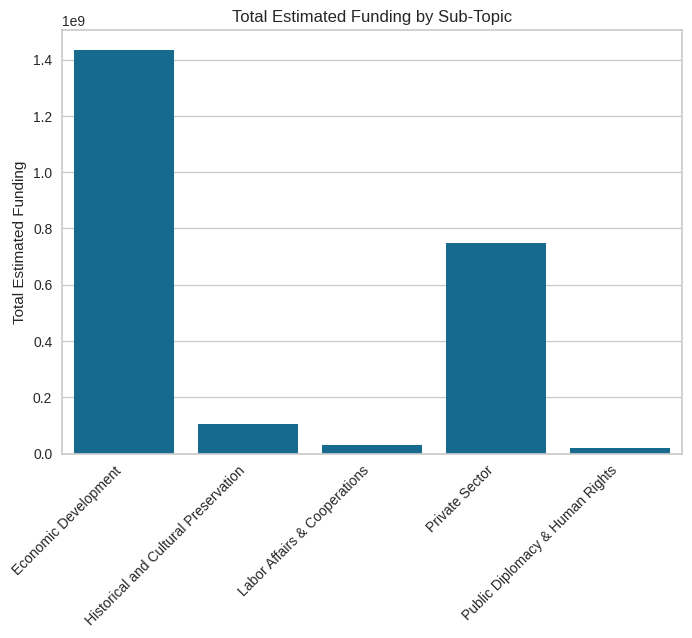

In [ ]:
sns.barplot(data=total_funding_other, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Total Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Total Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.show()

**Analysis**

This graph shows the same patterns seen in the previous two graphs, with economic development and the private sector dominating total grant funding in the 'other' category.

### **Environment Category Clustering**

#### Check for Duplicate Descriptions

In [ ]:
details_environment = details[details['official_category'] == 'environment']
details_environment.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,102.000000,102.000000,102.000000,102,102,101,101,87,1.020000e+02,1.020000e+02,1.020000e+02
mean,342574.598039,10.686275,2.107843,2022-11-24 13:10:35.294117632,2022-12-19 12:56:28.235294208,2023-10-05 03:05:20.792079104,2023-10-28 20:26:08.316831744,2024-04-13 00:00:00,3.261132e+08,2.108781e+08,4.673202e+05
min,103313.000000,0.000000,1.000000,2011-07-06 00:00:00,2011-07-07 00:00:00,2011-07-26 00:00:00,2011-07-26 00:00:00,2023-10-26 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,345571.750000,0.000000,1.000000,2023-01-23 18:00:00,2023-01-25 00:00:00,2023-10-16 00:00:00,2023-10-24 00:00:00,2023-12-04 12:00:00,0.000000e+00,1.000000e+05,0.000000e+00
50%,349822.000000,1.000000,1.000000,2023-08-18 00:00:00,2023-08-23 00:00:00,2023-11-08 00:00:00,2023-11-13 00:00:00,2023-12-16 00:00:00,9.400000e+05,1.000000e+06,0.000000e+00
75%,350208.750000,7.750000,3.000000,2023-09-14 00:00:00,2023-09-14 00:00:00,2023-12-19 00:00:00,2024-01-17 00:00:00,2024-04-26 00:00:00,8.000000e+06,5.210000e+06,5.000000e+04
max,350386.000000,115.000000,11.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2028-09-30 00:00:00,2028-09-30 00:00:00,2028-11-01 00:00:00,1.397000e+10,1.397000e+10,2.500000e+07
std,26864.318472,21.758795,1.861049,NaN,NaN,NaN,NaN,NaN,1.689151e+09,1.499377e+09,2.826956e+06


In [ ]:
details_environment = details_environment.drop_duplicates(subset="description")

In [ ]:
details_environment.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,88.000000,88.000000,88.000000,88,88,87,87,73,8.800000e+01,8.800000e+01,8.800000e+01
mean,341488.215909,11.113636,2.272727,2022-10-14 19:54:32.727272704,2022-11-12 19:05:27.272727296,2023-09-23 09:06:12.413793024,2023-10-20 22:04:08.275862016,2024-04-29 18:24:39.452054784,3.778524e+08,2.443111e+08,5.365530e+05
min,103313.000000,0.000000,1.000000,2011-07-06 00:00:00,2011-07-07 00:00:00,2011-07-26 00:00:00,2011-07-26 00:00:00,2023-10-26 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,344045.250000,0.000000,1.000000,2022-10-17 12:00:00,2022-10-17 12:00:00,2023-10-12 00:00:00,2023-10-17 12:00:00,2023-11-30 00:00:00,0.000000e+00,1.375000e+05,0.000000e+00
50%,349647.000000,1.000000,1.000000,2023-08-01 12:00:00,2023-08-15 12:00:00,2023-11-13 00:00:00,2023-11-16 00:00:00,2024-01-14 00:00:00,1.273000e+06,1.000000e+06,0.000000e+00
75%,350070.000000,7.250000,3.000000,2023-09-02 00:00:00,2023-09-08 00:00:00,2024-01-16 12:00:00,2024-02-06 12:00:00,2024-05-31 00:00:00,1.104050e+07,1.000000e+07,3.500000e+04
max,350380.000000,115.000000,11.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2028-09-30 00:00:00,2028-09-30 00:00:00,2028-11-01 00:00:00,1.397000e+10,1.397000e+10,2.500000e+07
std,28769.928547,23.292953,1.951877,NaN,NaN,NaN,NaN,NaN,1.814565e+09,1.612967e+09,3.040112e+06


#### **Text Embedding**

In [ ]:
embeddings_environment = embedding_model.encode(
    details_environment["description"].tolist(),   # convert to list for speed
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings_environment = np.asarray(embeddings_environment, dtype=np.float32)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
umap_model = umap.UMAP(
    n_components=15,
    n_neighbors=15,
    metric='cosine',
    random_state=42
)

embeddings_environment_umap = umap_model.fit_transform(embeddings_environment)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### **K-Means Clustering**

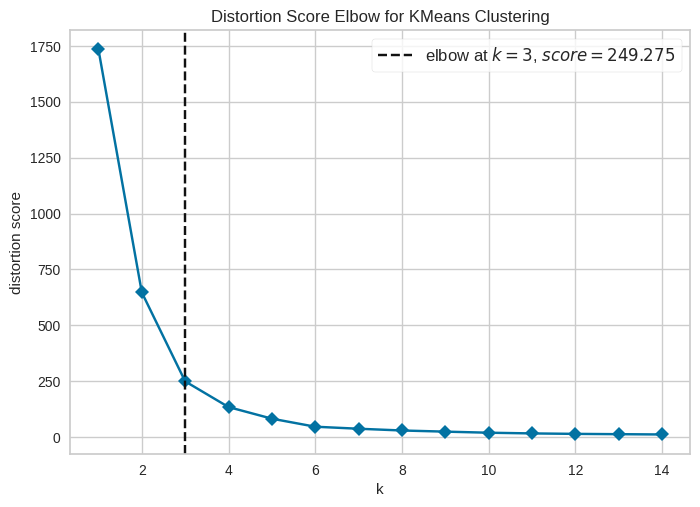

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
model = KMeans(
    init="k-means++", # enhanced initialization
    n_init=10,      # increase iterations
    max_iter=500,   # ensures convergence
    random_state=42
)

visualizer = KElbowVisualizer(
    model,
    k=(1, 15),                 # test cluster range
    metric="distortion",
    timings=False
)

visualizer.fit(embeddings_environment_umap)
visualizer.show()

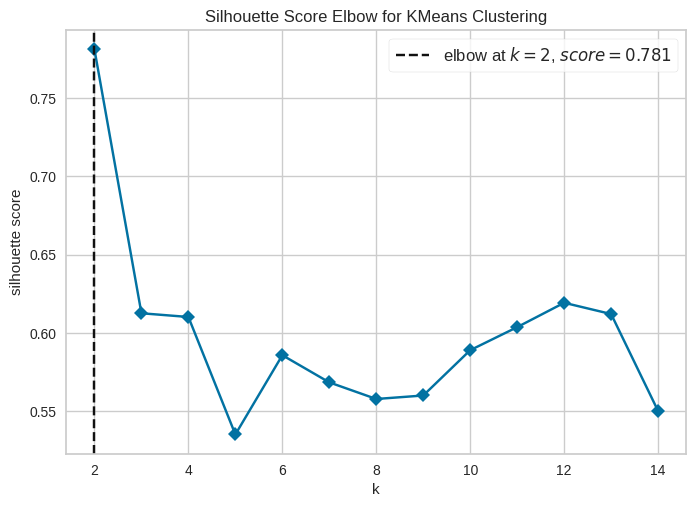

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
visualizer = KElbowVisualizer(
    model,
    k=(2, 15),                 # test cluster range
    metric="silhouette",
    timings=False
)

visualizer.fit(embeddings_environment_umap)
visualizer.show()

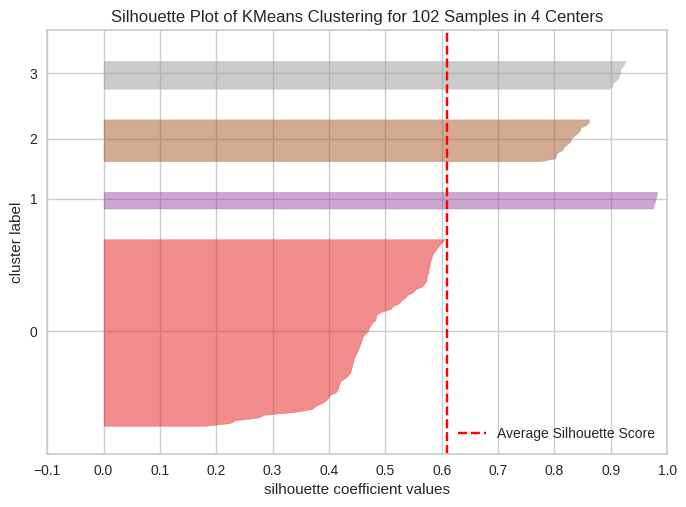

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 102 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
kmeans_model = model = KMeans(
    n_clusters=4,
    init="k-means++",
    n_init=10,
    max_iter=500,
    random_state=42
)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(embeddings_environment_umap)        # Fit the data to the visualizer
visualizer.show()

In [ ]:
# Fit the model and predict cluster labels, excluding the existing 'cluster_labels' column
details_environment['cluster_labels'] = kmeans_model.fit_predict(embeddings_environment_umap).astype(str)

# Display the value counts of the new cluster labels
print(details_environment['cluster_labels'].value_counts())


cluster_labels
0    68
2    16
3    11
1     7
Name: count, dtype: int64


**Analysis**
A k of 4 was chosen to optimized the key words identified in each cluster, while maintaining a reasonable silhouette score.

#### **Extracting Key Words From Each Cluster**

In [ ]:
word_tfidf_environment = word_vectorizer.fit_transform(details_environment['description'])
word_terms_environment = word_vectorizer.get_feature_names_out()

phrase_tfidf_environment = phrase_vectorizer.fit_transform(details_environment['description'])
phrase_terms_environment = phrase_vectorizer.get_feature_names_out()


In [ ]:
num_clusters_environment = details_environment['cluster_labels'].nunique()

for cluster_num in range(num_clusters_environment):

    cluster_mask = (details_environment['cluster_labels'] == str(cluster_num)).to_numpy()

    # WORDS
    cluster_word_matrix = word_tfidf_environment[cluster_mask]
    word_means = np.asarray(cluster_word_matrix.mean(axis=0)).flatten()

    top_word_indices = word_means.argsort()[::-1][:5]

    words = [
        (word_terms_environment[i], round(word_means[i], 4))
        for i in top_word_indices
    ]


    # PHRASES
    cluster_phrase_matrix = phrase_tfidf_environment[cluster_mask]
    phrase_means = np.asarray(cluster_phrase_matrix.mean(axis=0)).flatten()

    top_phrase_indices = phrase_means.argsort()[::-1][:5]

    phrases = [
        (phrase_terms_environment[i], round(phrase_means[i], 4))
        for i in top_phrase_indices
    ]

    print(f"\n========== Cluster {cluster_num} ==========")

    print("\nTop Words:")
    for word, score in words:
        print(f"{word:<20} {score}")

    print("\nTop Phrases:")
    for phrase, score in phrases:
        print(f"{phrase:<30} {score}")


========== Cluster 0 ==========

Top Words:
conservation         0.0584
species              0.0575
activity             0.0503
projects             0.0499
usaid                0.0489

Top Phrases:
fiscal year                    0.0869
united states                  0.0837
international development      0.0556
public law                     0.0556
cooperative agreements         0.0544

========== Cluster 1 ==========

Top Words:
wetland              0.5741
wetlands             0.2296
change               0.2091
seeks                0.1983
protection           0.181

Top Phrases:
wetland protection             0.1808
wetland protection management  0.1808
protection management          0.1808
epa seeks                      0.1748
climate change                 0.1646

========== Cluster 2 ==========

Top Words:
research             0.3014
data                 0.1393
disorders            0.1187
scientists           0.1081
development          0.1026

Top Phrases:
substance use           

**Environment Sub-Topics**

Cluster 0: Conservation & International Development

Cluster 1: Wetlands

Cluster 2: Substance Use & Scientific Research

Cluster 3: Environmental Education & Public Awareness

**Analysis**

Cluster 0 has the smallest average silhouette score, which aligns with the broad and varied key words identified, along with their low tfidf scores. Cluster 1 and 3 show clear sub-domains that offer useful information into what environment grants fund. Cluster 2 appears to capture 2 differ sub-topics.

#### **Cluster Analysis**

In [ ]:
# assign sub-topic labels to each environment grant
cluster_name_mapping = {
    '0': 'Conservation & International Development',
    '1': 'Wetlands',
    '2': 'Substance Use & Scientific Research',
    '3': 'Environmental Education & Public Awareness'
}

if 'cluster_labels' not in details_environment.columns:
    print("Error: 'cluster_labels' column not found. Please ensure the K-Means clustering cell was executed successfully.")
else:
    details_environment['cluster_labels'] = details_environment['cluster_labels'].map(cluster_name_mapping)

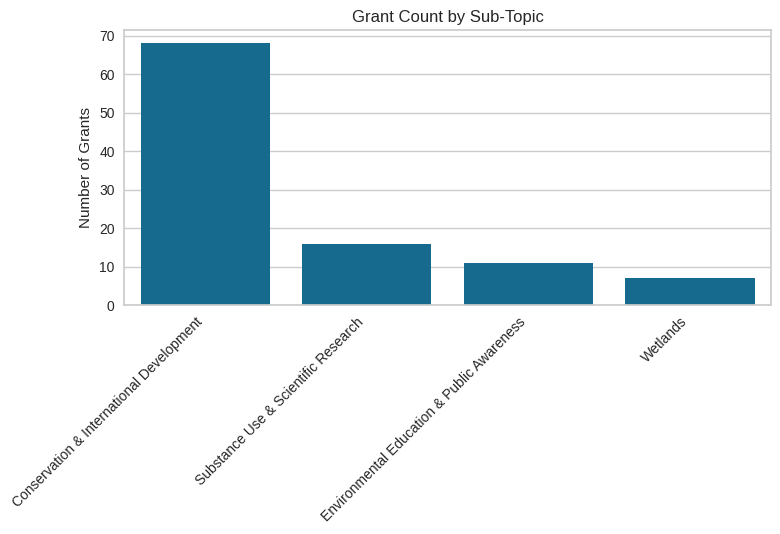

In [ ]:
#cluster count bar chart
sns.countplot(data=details_environment, x='cluster_labels', order=details_environment['cluster_labels'].value_counts().index)
plt.title("Grant Count by Sub-Topic")
plt.xlabel("")
plt.ylabel("Number of Grants")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analysis**

Given the broad nature of the dominant Conservation cluster, we can see that we were only able to capture a few sub-topics within the environment category. There are likely smaller sub-topics within the conservation cluster that our clustering was unable to capture. Our strongest clusters, wetlands and environmental education, make up the smallest proportions of this category.

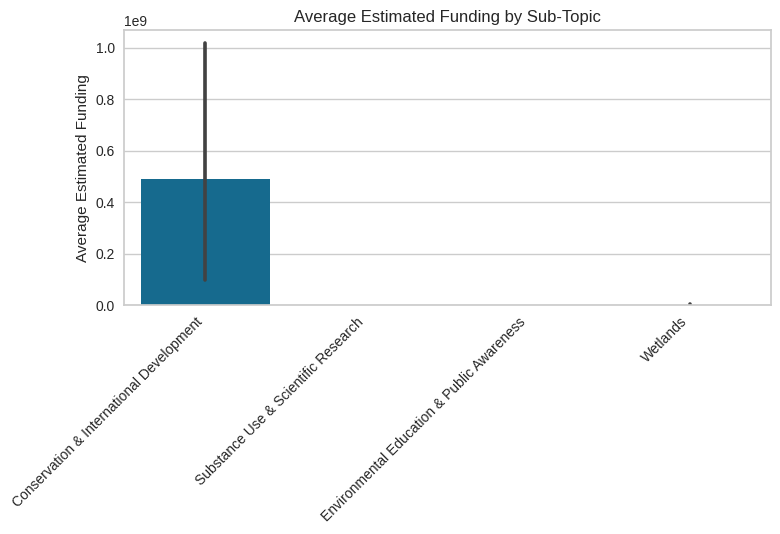

In [ ]:
#cluster by mean estimated funding
sns.barplot(data=details_environment, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Average Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Average Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analysis**

The poor clustering of our conservation cluster, dominates both the number of grants and the average funding of each grant, making it difficult to appropriately compare these sub-topics.

In [ ]:
total_funding_environment = pd.DataFrame(details_environment.groupby('cluster_labels')['estimated_total_program_funding'].sum())
total_funding_environment

,estimated_total_program_funding
cluster_labels,
Conservation & International Development,3.324362e+10
Environmental Education & Public Awareness,3.600000e+06
Substance Use & Scientific Research,0.000000e+00
Wetlands,1.632455e+07


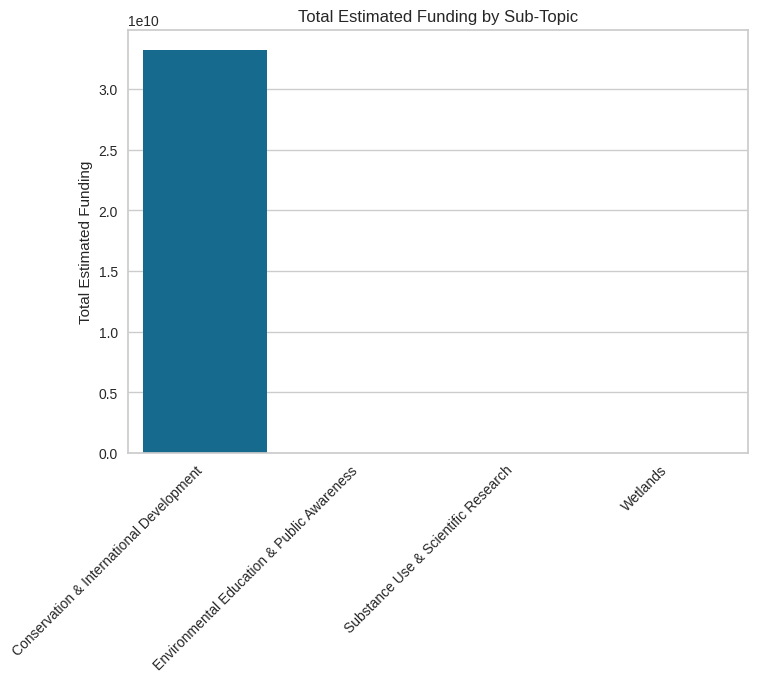

In [ ]:
sns.barplot(data=total_funding_environment, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Total Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Total Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.show()

**Analysis**

While the substance use cluster was our second largest cluster, there is a lack of data in funding of those grants. While the conservation cluster dominates the visual graph, we can see in our table that the wetlands and environmental education have strong funding in the environment category.

# **Analysis Summary**

Clustering analysis revealed meaningful sub-topics within broad grant categories, providing insights into funding priorities and potential gaps.

Within the Health category, Clinical Trials, Mental Health, Alzheimer’s Research, Occupational Safety, and International Development emerged as distinct sub-domains. Clinical trials represented the largest number of grants, reflecting their broad applicability, while international development had the highest average and total funding per grant, indicating concentrated investment in global health initiatives. Alzheimer’s research also emerged as a major focus area, highlighting its policy importance.

In Science, sub-topics included Engineering, Defense and Space, Earth and Climate Sciences, and Mathematical and Behavioral Sciences. Defense and space grants had the highest average funding, reflecting national strategic priorities. In contrast, mathematical and behavioral sciences had lower funding levels, suggesting potential underinvestment relative to other scientific domains.

Education grants revealed sub-topics including Substance Use and Brain Research, Cancer Research, Clinical Trials, and STEM Education. Although STEM education had fewer grants overall, it received the highest average funding per grant, indicating targeted investment in workforce and educational development.

The “Other” category was dominated by Economic Development and Private Sector initiatives, which accounted for the largest share of funding and grant volume. This suggests a strong emphasis on economic growth and workforce-related programs. Environmental grants showed two concrete sub-topics of Wetlands and Environmental Education; however, these sub-topics reflected a relatively small share of grants and funding.  

Overall, clustering uncovered meaningful sub-domains that are not visible within broad category labels. These results highlight uneven funding distribution across sub-topics and provide actionable insight into government funding priorities and potentially underserved areas.


**Limitations:** Grant descriptions were only available in the grant_opportunities_details dataset, which limited the amount of data points available for analysis. Furthermore, separating grants by category further limited the data. Only the top six categories had greater than 100 grants, so my analysis focused on clustering of those categories.

**AI Discolsure:** My written report includes a link to my conversations with ChatGPT, which helped me create select EDA graphs, ensure data cleaning was thorough, and research alternative clustering, text embedding, and optimization methods.

## Widget Removal fo GitHub Upload

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [214]:
!pip install nbformat

import nbformat

notebook_path = '/content/drive/MyDrive/MSBA Spring 2026/820 ML Group Project/M2 Work/Final Notebooks/Maggie_Croghan_M2.ipynb'  # change to your filename

nb = nbformat.read(notebook_path, as_version=4)

# Remove widgets metadata entirely
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, notebook_path)

print("Widgets metadata removed successfully.")


Widgets metadata removed successfully.
